# The imports

In [12]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Load the Resutls File

In [13]:
file_name = "general_results.pkl"

In [14]:
dictionaries = pickle.load(open(file_name, "rb"))

In [15]:
# in a recursvive way, plot the tree structure of the dictionaries
ks0 = list(dictionaries.keys())
def print_keys(d,top=5,depth=0):
    ks = list(d.keys())
    if len(ks) > top:
        ks = ks[:top]
    ks += ["..."] if len(d.keys()) > top else []
    for k in ks:
        if isinstance(d[k], dict):
            print("  " * depth + str(k), "\t level", depth)
            print_keys(d = d[k], top = top, depth = depth + 1)
        else:
            print("  " * (depth + 1) + str(k) + ": " + str(d[k].shape) + "\t level", depth)
            print("  " * (depth + 1) + str(d[k].iloc[:3,:3]).replace("\n", "\n"+"  "*4))
            print("  " * (depth + 1) + str(k) + ": " + str(...))
print_keys(dictionaries)

toy_dataset 	 level 0
  rejection_quality_dict 	 level 1
      random_forest: (362, 32)	 level 2
                                             0.99       0.96       0.95
        PlugInRule                              0.0   8.178571  10.904762
        PlugInRuleAUC                           0.0  10.904762   5.452381
        growingspheres_CFDistRejector_inf_min   0.0  16.357143  10.904762
      random_forest: Ellipsis
      mlp: (362, 32)	 level 2
                                             0.99       0.96       0.95
        PlugInRule                              0.0  51.818182  10.363636
        PlugInRuleAUC                           0.0   0.000000   0.000000
        growingspheres_CFDistRejector_inf_min   0.0  51.818182  12.436364
      mlp: Ellipsis
      xgboost: (362, 32)	 level 2
                                             0.99       0.96       0.95
        PlugInRule                              0.0  12.888889  12.888889
        PlugInRuleAUC                           0.0   2

In [16]:
#dictionaries[k0][k1][k2]

In [17]:
for k0 in dictionaries.keys():
    print("Dataset:", k0)
    for k1 in dictionaries[k0].keys():
        print("  Classifier:", k1)
        for k2 in dictionaries[k0][k1].keys():
            print("    Measure:", k2)
            if isinstance(dictionaries[k0][k1][k2], pd.DataFrame):
                print("      Shape:", dictionaries[k0][k1][k2].shape)
                
                print("random 5 index:", dictionaries[k0][k1][k2].sample(5).index.tolist())
                assert "PlugInRule" in dictionaries[k0][k1][k2].index, "PlugIn not found in index"
            else:
                print("      Type:", type(dictionaries[k0][k1][k2]))
            break
        

Dataset: toy_dataset
  Classifier: rejection_quality_dict
    Measure: random_forest
      Shape: (362, 32)
random 5 index: ['lore_CFDistRejector_cosine_min', 'ils<latent_CFDistRejector_centered_l2_mean', 'dice_CFDistRejector_centered_cosine_max_gamma', 'growingspheres_CFDistRejector_sqeuclidean_min_gamma', 'lore_CFDistRejector_braycurtis_mean']
  Classifier: classification_quality_dict
    Measure: random_forest
      Shape: (362, 32)
random 5 index: ['dice_CFDistRejector_centered_l2_min', 'dice_CFDistRejector_inf_max', 'lore_CFDistRejector_kendall_mean', 'growingspheres_CFDistRejector_l2_mean_gamma', 'growingspheres_CFDistRejector_sqeuclidean_max_gamma']
  Classifier: rejected_by_coverage
    Measure: random_forest
      Shape: (362, 32)
random 5 index: ['lore_CFDistRejector_mae_max', 'dice_CFDistRejector_braycurtis_min', 'ils_CFDistRejector_canberra_max', 'lore_CFDistRejector_kendall_mean', 'ils_CFDistRejector_l2_mean_gamma']
Dataset: german_credit
  Classifier: rejection_quality_di

In [18]:
# keep only the scores down to a target coverage of 0.6 ? 
only_coverage = 0.6
for k0 in dictionaries.keys():
    for k1 in dictionaries[k0].keys():
        for k2 in dictionaries[k0][k1].keys():
            if isinstance(dictionaries[k0][k1][k2], pd.DataFrame):
                df = dictionaries[k0][k1][k2]
                # keep only rows where coverage is less than 0.6.
                # the value of the column name is the target coverage itself, so we can use it to filter the rows.
                df_after = df.copy()
                # drop the columns that are smaller than the target coverage "only_coverage"
                df_after = df_after.loc[:, df_after.columns >= only_coverage]

                dictionaries[k0][k1][k2] = df_after

In [19]:
for k0 in dictionaries.keys():
    print("Dataset:", k0)
    for k1 in dictionaries[k0].keys():
        print("  Classifier:", k1)
        for k2 in dictionaries[k0][k1].keys():
            print("    Measure:", k2)
            if isinstance(dictionaries[k0][k1][k2], pd.DataFrame):
                print("      Shape:", dictionaries[k0][k1][k2].shape)
                print("      Columns:", dictionaries[k0][k1][k2].columns.tolist()[-2:])
                
                print("random 5 index:", dictionaries[k0][k1][k2].sample(5).index.tolist())
                assert "PlugInRule" in dictionaries[k0][k1][k2].index, "PlugIn not found in index"
            else:
                print("      Type:", type(dictionaries[k0][k1][k2]))
            break
        break
    break


Dataset: toy_dataset
  Classifier: rejection_quality_dict
    Measure: random_forest
      Shape: (362, 16)
      Columns: [0.61, 0.6]
random 5 index: ['ils<latent_CFDistRejector_cosine_max', 'ils<latent_CFDistRejector_kendall_max', 'ils_CFDistRejector_braycurtis_mean', 'lore_CFDistRejector_braycurtis_mean', 'growingspheres_CFDistRejector_correlation_mean_gamma']


In [20]:
dictionaries[k0][k1][k2].index

Index(['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min',
       'growingspheres_CFDistRejector_inf_min_gamma',
       'growingspheres_CFDistRejector_inf_max',
       'growingspheres_CFDistRejector_inf_max_gamma',
       'growingspheres_CFDistRejector_inf_mean',
       'growingspheres_CFDistRejector_inf_mean_gamma',
       'growingspheres_CFDistRejector_l2_min',
       'growingspheres_CFDistRejector_l2_min_gamma',
       ...
       'dice_CFDistRejector_centered_cosine_max',
       'dice_CFDistRejector_centered_cosine_max_gamma',
       'dice_CFDistRejector_centered_cosine_mean',
       'dice_CFDistRejector_centered_cosine_mean_gamma',
       'dice_CFDistRejector_centered_l2_min',
       'dice_CFDistRejector_centered_l2_min_gamma',
       'dice_CFDistRejector_centered_l2_max',
       'dice_CFDistRejector_centered_l2_max_gamma',
       'dice_CFDistRejector_centered_l2_mean',
       'dice_CFDistRejector_centered_l2_mean_gamma'],
      dtype='object', length=362)

In [21]:
import pandas as pd

In [22]:
'''
dictionaries2 = dictionaries.copy()
# keep only the PlugIn methods, and ils and ils_latent with cosine distance and wasserstein, only the max aggregation and gamma distribution
for k0 in dictionaries2.keys():
    print("Dataset:", k0)
    for k1 in dictionaries2[k0].keys():
        print("  Classifier:", k1)
        for k2 in dictionaries2[k0][k1].keys():
            print("    Measure:", k2)
            if isinstance(dictionaries2[k0][k1][k2], pd.DataFrame):
                # the names of our proposals are the indexes of the DataFrame
                df = dictionaries2[k0][k1][k2]
                # keep only the PlugIn methods, and ils and ils_latent with cosine distance and wasserstein, only the max aggregation and gamma distribution
                df = df[(df.index.str.contains('PlugInRule') | df.index.str.contains('ils') | df.index.str.contains('ils_latent'))]
                df = df[
                          (df.index.str.contains('cosine') | df.index.str.contains('wasserstein')) &
                          (df.index.str.contains('max')) &
                          (df.index.str.contains('gamma'))]
                dictionaries2[k0][k1][k2] = df
                '''

'\ndictionaries2 = dictionaries.copy()\n# keep only the PlugIn methods, and ils and ils_latent with cosine distance and wasserstein, only the max aggregation and gamma distribution\nfor k0 in dictionaries2.keys():\n    print("Dataset:", k0)\n    for k1 in dictionaries2[k0].keys():\n        print("  Classifier:", k1)\n        for k2 in dictionaries2[k0][k1].keys():\n            print("    Measure:", k2)\n            if isinstance(dictionaries2[k0][k1][k2], pd.DataFrame):\n                # the names of our proposals are the indexes of the DataFrame\n                df = dictionaries2[k0][k1][k2]\n                # keep only the PlugIn methods, and ils and ils_latent with cosine distance and wasserstein, only the max aggregation and gamma distribution\n                df = df[(df.index.str.contains(\'PlugInRule\') | df.index.str.contains(\'ils\') | df.index.str.contains(\'ils_latent\'))]\n                df = df[\n                          (df.index.str.contains(\'cosine\') | df.index.st

In [23]:
import pandas as pd
import numpy as np
import re
from typing import Dict, List, Tuple, Optional, Union
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

class ExperimentAnalyzer:
    def __init__(self, nested_results: Dict):
        """
        Initialize analyzer with nested results dictionary
        
        Args:
            nested_results: Dict[dataset][metric][model] = DataFrame(482, 32)
        """
        self.nested_results = nested_results
        self.method_components = {}
        self._parse_method_names()
        
    def _parse_method_names(self):
        """Parse method names to extract components"""
        # Get all method names from first available dataframe
        sample_df = None
        for dataset in self.nested_results:
            for metric in self.nested_results[dataset]:
                for model in self.nested_results[dataset][metric]:
                    sample_df = self.nested_results[dataset][metric][model]
                    break
                if sample_df is not None:
                    break
            if sample_df is not None:
                break
        
        if sample_df is None:
            raise ValueError("No dataframes found in nested results")
            
        method_names = sample_df.index.tolist()
        
        for method in method_names:
            self.method_components[method] = self._parse_single_method(method)
    
    def _parse_single_method(self, method_name: str) -> Dict[str, str]:
        """Parse a single method name into components"""
        components = {
            'cf_generator': None,
            'rejector_type': None,
            'distance': None,
            'aggregation': None,
            'distribution': None,
            'is_baseline': False
        }
        
        # Check if it's a baseline (assuming baselines don't follow the structured pattern)
        if '_' not in method_name or len(method_name.split('_')) < 4:
            components['is_baseline'] = True
            components['cf_generator'] = method_name
            return components
        
        # Parse structured method name
        # Pattern: cf_generator_rejector_distance_aggregation[_gamma]
        parts = method_name.split('_')
        
        if len(parts) >= 4:
            # Find rejector type (assuming it contains "Rejector")
            rejector_idx = None
            for i, part in enumerate(parts):
                if 'Rejector' in part:
                    rejector_idx = i
                    break
            
            if rejector_idx is not None:
                # CF generator is everything before rejector
                components['cf_generator'] = '_'.join(parts[:rejector_idx])
                components['rejector_type'] = parts[rejector_idx]
                
                # Remaining parts are distance, aggregation, and possibly gamma
                remaining = parts[rejector_idx + 1:]
                if len(remaining) >= 2:
                    components['distance'] = remaining[0]
                    components['aggregation'] = remaining[1]
                    
                    # Check for gamma distribution flag
                    if len(remaining) > 2 and 'gamma' in remaining:
                        components['distribution'] = 'gamma'
        
        return components
    
    def get_methods_by_component(self, component: str, value: str) -> List[str]:
        """Get all methods that have a specific component value"""
        return [method for method, components in self.method_components.items()
                if components.get(component) == value]
    
    def filter_methods(self, **filters) -> List[str]:
        """
        Filter methods by component values
        
        Args:
            **filters: component_name=value pairs
            
        Example:
            filter_methods(cf_generator='ils<latent', distance='l2', aggregation='max')
        """
        filtered_methods = []
        
        for method, components in self.method_components.items():
            match = True
            for component, value in filters.items():
                if components.get(component) != value:
                    match = False
                    break
            if match:
                filtered_methods.append(method)
                
        return filtered_methods
    
    def get_component_values(self, component: str) -> List[str]:
        """Get all unique values for a specific component"""
        values = set()
        for components in self.method_components.values():
            value = components.get(component)
            if value is not None:
                values.add(value)
        return sorted(list(values))
    
    def extract_data_for_analysis(self, 
                                datasets: Optional[List[str]] = None,
                                metrics: Optional[List[str]] = None,
                                models: Optional[List[str]] = None,
                                methods: Optional[List[str]] = None,
                                confidence_level: Union[int, str] = 'mean') -> pd.DataFrame:
        """
        Extract data for statistical analysis
        
        Args:
            datasets: List of datasets to include (None = all)
            metrics: List of metrics to include (None = all)
            models: List of models to include (None = all)
            methods: List of methods to include (None = all)
            confidence_level: Column index to use or 'mean' for average across all columns
            
        Returns:
            DataFrame with columns: dataset, metric, model, method, value, [components...]
        """
        results = []
        
        # Set defaults
        if datasets is None:
            datasets = list(self.nested_results.keys())
        if metrics is None:
            metrics = list(next(iter(self.nested_results.values())).keys())
        if models is None:
            models = list(next(iter(next(iter(self.nested_results.values())).values())).keys())
        
        for dataset in datasets:
            if dataset not in self.nested_results:
                continue
                
            for metric in metrics:
                if metric not in self.nested_results[dataset]:
                    continue
                    
                for model in models:
                    if model not in self.nested_results[dataset][metric]:
                        continue
                    
                    df = self.nested_results[dataset][metric][model]
                    
                    # Filter methods if specified
                    available_methods = df.index.tolist()
                    if methods is not None:
                        available_methods = [m for m in available_methods if m in methods]
                    
                    for method in available_methods:
                        # Extract value based on confidence_level
                        if confidence_level == 'mean':
                            value = df.loc[method].mean()
                        else:
                            value = df.loc[method, confidence_level]
                        
                        # Create result row
                        row = {
                            'dataset': dataset,
                            'metric': metric,
                            'model': model,
                            'method': method,
                            'value': value
                        }
                        
                        # Add component information
                        components = self.method_components.get(method, {})
                        row.update(components)
                        
                        results.append(row)
        
        return pd.DataFrame(results)
    
    def compare_methods_across_datasets(self, 
                                      methods: List[str],
                                      metric: str = 'rejection_quality_dict',
                                      model: Optional[str] = None,
                                      confidence_level: Union[int, str] = 'mean') -> pd.DataFrame:
        """Compare specific methods across all datasets"""
        
        models_to_use = [model] if model else list(next(iter(next(iter(self.nested_results.values())).values())).keys())
        
        comparison_data = self.extract_data_for_analysis(
            metrics=[metric],
            models=models_to_use,
            methods=methods,
            confidence_level=confidence_level
        )
        
        return comparison_data
    
    def find_best_method_by_component(self,
                                    component: str,
                                    component_value: str,
                                    metric: str = 'rejection_quality_dict',
                                    aggregation: str = 'mean') -> Dict:
        """
        Find the best method with a specific component value
        
        Args:
            component: Component to filter by (e.g., 'distance', 'cf_generator')
            component_value: Value of component (e.g., 'l2', 'ils<latent')
            metric: Metric to evaluate
            aggregation: How to aggregate across datasets/models ('mean', 'median', 'max', 'min')
        """
        
        # Get methods with the specified component
        candidate_methods = self.get_methods_by_component(component, component_value)
        
        if not candidate_methods:
            return {'error': f'No methods found with {component}={component_value}'}
        
        # Extract data for these methods
        data = self.extract_data_for_analysis(
            metrics=[metric],
            methods=candidate_methods,
            confidence_level='mean'
        )
        
        # Aggregate performance across datasets and models
        if aggregation == 'mean':
            method_performance = data.groupby('method')['value'].mean()
        elif aggregation == 'median':
            method_performance = data.groupby('method')['value'].median()
        elif aggregation == 'max':
            method_performance = data.groupby('method')['value'].max()
        elif aggregation == 'min':
            method_performance = data.groupby('method')['value'].min()
        else:
            raise ValueError(f"Unknown aggregation: {aggregation}")
        
        best_method = method_performance.idxmax()
        best_value = method_performance.max()
        
        return {
            'best_method': best_method,
            'best_value': best_value,
            'all_performance': method_performance.to_dict(),
            'component': component,
            'component_value': component_value
        }
    
    def statistical_comparison(self, 
                             method_groups: Dict[str, List[str]],
                             metric: str = 'rejection_quality_dict',
                             test_type: str = 'friedman') -> Dict:
        """
        Perform statistical tests between method groups
        
        Args:
            method_groups: Dict of group_name -> list of methods
            metric: Metric to test
            test_type: Type of test ('friedman', 't_test', 'anova')
        """
        try:
            from scipy import stats
        except ImportError:
            return {'error': 'scipy required for statistical tests'}
        
        # Extract data for all methods
        all_methods = []
        for methods in method_groups.values():
            all_methods.extend(methods)
        
        data = self.extract_data_for_analysis(
            metrics=[metric],
            methods=all_methods,
            confidence_level='mean'
        )
        
        # Prepare data for statistical testing
        results = {'test_type': test_type, 'groups': {}}
        
        for group_name, methods in method_groups.items():
            group_data = data[data['method'].isin(methods)]
            results['groups'][group_name] = {
                'methods': methods,
                'mean_performance': group_data['value'].mean(),
                'std_performance': group_data['value'].std(),
                'values': group_data['value'].tolist()
            }
        
        # Perform statistical test
        if test_type == 'friedman' and len(method_groups) > 2:
            group_values = [results['groups'][group]['values'] for group in method_groups.keys()]
            stat, p_value = stats.friedmanchisquare(*group_values)
            results['test_statistic'] = stat
            results['p_value'] = p_value
            
        elif test_type == 't_test' and len(method_groups) == 2:
            group_names = list(method_groups.keys())
            group1_values = results['groups'][group_names[0]]['values']
            group2_values = results['groups'][group_names[1]]['values']
            stat, p_value = stats.ttest_ind(group1_values, group2_values)
            results['test_statistic'] = stat
            results['p_value'] = p_value
            
        return results
    
    def create_analysis_report(self, output_file: str = 'analysis_report.txt'):
        """Generate a comprehensive analysis report"""
        
        report = []
        report.append("=== EXPERIMENT ANALYSIS REPORT ===\n")
        
        # Basic statistics
        report.append("BASIC STATISTICS:")
        report.append(f"- Total datasets: {len(self.nested_results)}")
        report.append(f"- Total methods: {len(self.method_components)}")
        
        # Component analysis
        report.append("\nCOMPONENT ANALYSIS:")
        for component in ['cf_generator', 'rejector_type', 'distance', 'aggregation']:
            values = self.get_component_values(component)
            report.append(f"- {component}: {len(values)} options = {values}")
        
        # Best method analysis for each component
        report.append("\nBEST METHOD BY COMPONENT:")
        for component in ['cf_generator', 'distance', 'aggregation']:
            values = self.get_component_values(component)
            for value in values:
                if value:  # Skip None values
                    best = self.find_best_method_by_component(component, value)
                    if 'error' not in best:
                        report.append(f"- Best {component}='{value}': {best['best_method']} (score: {best['best_value']:.4f})")
        
        # Save report
        with open(output_file, 'w') as f:
            f.write('\n'.join(report))
        
        return '\n'.join(report)


# Helper function to prepare data for your create_df_and_check function
def prepare_for_visualization(analyzer: ExperimentAnalyzer,
                            methods: List[str],
                            dataset: str,
                            metric: str,
                            model: str) -> Tuple[List[str], np.ndarray]:
    """
    Prepare data for your create_df_and_check function
    
    Returns:
        methods_names: List of method names
        values: numpy array of shape (n_methods, 32) for confidence levels
    """
    
    if dataset not in analyzer.nested_results:
        raise ValueError(f"Dataset {dataset} not found")
    if metric not in analyzer.nested_results[dataset]:
        raise ValueError(f"Metric {metric} not found for dataset {dataset}")
    if model not in analyzer.nested_results[dataset][metric]:
        raise ValueError(f"Model {model} not found for dataset {dataset} and metric {metric}")
    
    df = analyzer.nested_results[dataset][metric][model]
    
    # Filter methods that exist in the dataframe
    available_methods = [m for m in methods if m in df.index]
    
    if not available_methods:
        raise ValueError("None of the specified methods found in the data")
    
    # Extract values
    values = df.loc[available_methods].values  # Shape: (n_methods, 32)
    
    return available_methods, values


# Specific analysis functions for your research questions
class ResearchQuestionAnalyzer:
    def __init__(self, analyzer: ExperimentAnalyzer):
        self.analyzer = analyzer
    
    def find_overall_best_method(self, 
                               metric: str = 'rejection_quality_dict',
                               aggregation: str = 'mean') -> Dict:
        """Find the best method overall across all datasets and models"""
        
        data = self.analyzer.extract_data_for_analysis(
            metrics=[metric],
            confidence_level='mean'
        )
        
        # Aggregate across all datasets and models
        if aggregation == 'mean':
            method_scores = data.groupby('method')['value'].mean()
        elif aggregation == 'median':
            method_scores = data.groupby('method')['value'].median()
        else:
            method_scores = data.groupby('method')['value'].agg(aggregation)
        
        best_method = method_scores.idxmax()
        best_score = method_scores.max()
        
        # Get top 10 methods
        top_methods = method_scores.nlargest(10)
        
        return {
            'best_method': best_method,
            'best_score': best_score,
            'top_10_methods': top_methods.to_dict(),
            'method_components': self.analyzer.method_components.get(best_method, {}),
            'analysis_details': {
                'metric': metric,
                'aggregation': aggregation,
                'total_methods_compared': len(method_scores)
            }
        }
    
    def compare_cf_generators(self, 
                            cf_gen1: str, 
                            cf_gen2: str,
                            model: str = 'mlp',
                            metric: str = 'rejection_quality_dict') -> Dict:
        """Compare two counterfactual generators for a specific model"""
        
        methods1 = self.analyzer.get_methods_by_component('cf_generator', cf_gen1)
        methods2 = self.analyzer.get_methods_by_component('cf_generator', cf_gen2)
        
        data1 = self.analyzer.extract_data_for_analysis(
            metrics=[metric],
            models=[model],
            methods=methods1,
            confidence_level='mean'
        )
        
        data2 = self.analyzer.extract_data_for_analysis(
            metrics=[metric],
            models=[model],
            methods=methods2,
            confidence_level='mean'
        )
        
        # Calculate performance statistics
        stats1 = {
            'mean': data1['value'].mean(),
            'std': data1['value'].std(),
            'median': data1['value'].median(),
            'max': data1['value'].max(),
            'min': data1['value'].min(),
            'count': len(data1)
        }
        
        stats2 = {
            'mean': data2['value'].mean(),
            'std': data2['value'].std(),
            'median': data2['value'].median(),
            'max': data2['value'].max(),
            'min': data2['value'].min(),
            'count': len(data2)
        }
        
        # Determine winner
        winner = cf_gen1 if stats1['mean'] > stats2['mean'] else cf_gen2
        
        # Statistical significance test
        try:
            from scipy import stats as scipy_stats
            if len(data1) > 1 and len(data2) > 1:
                t_stat, p_value = scipy_stats.ttest_ind(data1['value'], data2['value'])
                statistical_test = {
                    'test_type': 't-test',
                    'statistic': t_stat,
                    'p_value': p_value,
                    'significant': p_value < 0.05,
                    'effect_size': (stats1['mean'] - stats2['mean']) / 
                                 ((stats1['std']**2 + stats2['std']**2) / 2)**0.5 if (stats1['std'] > 0 or stats2['std'] > 0) else 0
                }
            else:
                statistical_test = {'error': 'Insufficient data for statistical test'}
        except ImportError:
            statistical_test = {'error': 'scipy required for statistical tests'}
        
        return {
            'comparison': f"{cf_gen1} vs {cf_gen2}",
            'model': model,
            'metric': metric,
            'winner': winner,
            'winner_advantage': abs(stats1['mean'] - stats2['mean']),
            f'{cf_gen1}_stats': stats1,
            f'{cf_gen2}_stats': stats2,
            'statistical_significance': statistical_test,
            'detailed_data': {
                cf_gen1: data1,
                cf_gen2: data2
            }
        }
    
    def find_best_distance_metric(self, 
                                distance_type: str = None,
                                metric: str = 'rejection_quality_dict') -> Dict:
        """Find the best distance metric across all datasets and models"""
        
        if distance_type:
            # Find best method with specific distance
            return self.analyzer.find_best_method_by_component(
                'distance', distance_type, metric
            )
        else:
            # Compare all distance metrics
            distances = self.analyzer.get_component_values('distance')
            distance_performance = {}
            
            for distance in distances:
                if distance:  # Skip None values
                    best = self.analyzer.find_best_method_by_component(
                        'distance', distance, metric
                    )
                    if 'error' not in best:
                        distance_performance[distance] = {
                            'best_method': best['best_method'],
                            'best_score': best['best_value']
                        }
            
            # Find overall best distance
            if distance_performance:
                best_distance = max(distance_performance.items(), 
                                  key=lambda x: x[1]['best_score'])
                
                # Cross-distance statistical comparison
                distance_groups = {}
                for distance in distances[:4]:  # Compare top 4 distances
                    if distance:
                        methods = self.analyzer.get_methods_by_component('distance', distance)
                        if methods:
                            distance_groups[distance] = methods
                
                cross_distance_stats = {}
                if len(distance_groups) > 1:
                    cross_distance_stats = self.analyzer.statistical_comparison(
                        method_groups=distance_groups,
                        metric=metric,
                        test_type='friedman' if len(distance_groups) > 2 else 't_test'
                    )
                
                return {
                    'best_distance': best_distance[0],
                    'best_score': best_distance[1]['best_score'],
                    'best_method': best_distance[1]['best_method'],
                    'all_distances': distance_performance,
                    'cross_distance_comparison': cross_distance_stats
                }
            else:
                return {'error': 'No distance metrics found'}
    
    def create_comparison_for_visualization(self,
                                          filter_criteria: Dict,
                                          dataset: Union[str, List[str]] = "all",
                                          metric: Union[str, List[str]] = "all", 
                                          model: Union[str, List[str]] = "all",
                                          top_n: int = 10,
                                          aggregation_method: str = 'mean',
                                          confidence_level: Union[int, str] = 'mean') -> Tuple[List[str], np.ndarray, str]:
        """
        Create filtered method comparison ready for your visualization function
        
        Args:
            filter_criteria: Dict of component filters (e.g., {'distance': 'minkowski'})
            dataset: Dataset name, list of datasets, or "all" for all datasets
            metric: Metric name, list of metrics, or "all" for all metrics  
            model: Model name, list of models, or "all" for all models
            top_n: Number of top methods to include
            aggregation_method: How to aggregate across multiple datasets/metrics/models ('mean', 'median', 'max', 'min')
            confidence_level: Column index to use or 'mean' for average across confidence levels
            
        Returns:
            method_names, values_array, title_for_plot
        """
        always_include = ["PlugInRule", "PlugInRuleAUC"]
        # Handle "all" keywords and convert to lists
        def resolve_selection(selection, available_options):
            if selection == "all":
                return available_options
            elif isinstance(selection, str):
                return [selection]
            elif isinstance(selection, list):
                return selection
            else:
                raise ValueError(f"Invalid selection type: {type(selection)}")
        
        # Get available options
        available_datasets = list(self.analyzer.nested_results.keys())
        available_metrics = list(next(iter(self.analyzer.nested_results.values())).keys())
        available_models = list(next(iter(next(iter(self.analyzer.nested_results.values())).values())).keys())
        
        # Resolve selections
        datasets = resolve_selection(dataset, available_datasets)
        metrics = resolve_selection(metric, available_metrics)
        models = resolve_selection(model, available_models)
        
        # Filter methods based on criteria
        filtered_methods = self.analyzer.filter_methods(**filter_criteria)
        
        if not filtered_methods:
            raise ValueError(f"No methods found matching criteria: {filter_criteria}")
        
        # Always include specified baseline methods if they exist
        
        print(f"Filtered methods count: {len(filtered_methods)}", filtered_methods)
        
        # Get performance data to rank methods
        data = self.analyzer.extract_data_for_analysis(
            datasets=datasets,
            metrics=metrics,
            models=models,
            methods=filtered_methods,
            confidence_level=confidence_level
        )
        
        if len(data) == 0:
            raise ValueError("No data found for the specified combination")
        
        # Aggregate performance across multiple datasets/metrics/models if needed
        if len(datasets) > 1 or len(metrics) > 1 or len(models) > 1:
            if aggregation_method == 'mean':
                method_performance = data.groupby('method')['value'].mean()
            elif aggregation_method == 'median':
                method_performance = data.groupby('method')['value'].median()
            elif aggregation_method == 'max':
                method_performance = data.groupby('method')['value'].max()
            elif aggregation_method == 'min':
                method_performance = data.groupby('method')['value'].min()
            else:
                raise ValueError(f"Unknown aggregation method: {aggregation_method}")
            
            # Get top methods based on aggregated performance
            if metric == "rejected_by_coverage":
                top_methods = method_performance.nlargest(top_n).index.tolist()
            else:
                top_methods = method_performance.nsmallest(top_n).index.tolist()
            
            # For visualization, we need to pick a specific dataset/metric/model combination
            # Use the first available combination
            viz_dataset = datasets[0]
            viz_metric = metrics[0] 
            viz_model = models[0]
            
        else:
            # Single combination case
            top_methods_data = data.nlargest(top_n, 'value')
            top_methods = top_methods_data['method'].tolist()
            viz_dataset = datasets[0]
            viz_metric = metrics[0]
            viz_model = models[0]
        for baseline in always_include:
            if not baseline in top_methods and baseline in self.analyzer.method_components:
                top_methods.append(baseline)
        # Prepare data for visualization using the specific combination
        method_names, values = prepare_for_visualization(
            self.analyzer, top_methods, viz_dataset, viz_metric, viz_model
        )
        
        # Create descriptive title
        filter_desc = ', '.join([f"{k}={v}" for k, v in filter_criteria.items()])
        
        if len(datasets) > 1 or len(metrics) > 1 or len(models) > 1:
            context_desc = f"across {len(datasets)} datasets, {len(metrics)} metrics, {len(models)} models"
            agg_desc = f"(ranked by {aggregation_method})"
            title = f"Top {len(method_names)} methods {agg_desc}: {filter_desc} {context_desc}"
        else:
            context_desc = f"{viz_dataset}/{viz_metric}/{viz_model}"
            title = f"Top {len(method_names)} methods: {filter_desc} on {context_desc}"
        
        return method_names, values, title
    
    def comprehensive_analysis_summary(self) -> Dict:
        """Generate a comprehensive summary of all key findings"""
        
        summary = {
            'overall_best': self.find_overall_best_method(),
            'best_by_distance': self.find_best_distance_metric(),
            'cf_generator_comparison': {},
            'key_insights': []
        }
        
        # Compare main CF generators
        cf_generators = self.analyzer.get_component_values('cf_generator')
        main_cf_gens = [cf for cf in cf_generators if cf and not any(
            baseline_indicator in cf.lower() 
            for baseline_indicator in ['baseline', 'random', 'simple']
        )][:4]  # Top 4 CF generators
        
        for i, cf_gen in enumerate(main_cf_gens):
            for j, other_cf_gen in enumerate(main_cf_gens[i+1:], i+1):
                comparison = self.compare_cf_generators(cf_gen, other_cf_gen)
                summary['cf_generator_comparison'][f"{cf_gen}_vs_{other_cf_gen}"] = {
                    'winner': comparison['winner'],
                    'advantage': comparison['winner_advantage'],
                    'statistical_significance': comparison.get('statistical_significance', {})
                }
        
        # Generate insights
        best_method = summary['overall_best']['best_method']
        best_components = summary['overall_best']['method_components']
        
        summary['key_insights'].extend([
            f"Overall best method: {best_method}",
            f"Best CF generator: {best_components.get('cf_generator', 'Unknown')}",
            f"Best distance metric: {summary['best_by_distance']['best_distance']}",
            f"Best aggregation: {best_components.get('aggregation', 'Unknown')}"
        ])
        
        return summary


# Advanced analysis functions
def find_best_generator(nested_results: Dict, 
                       metric: str = 'rejection_quality_dict',
                       top_n_methods_per_generator: int = 5,
                       include_visualization_data: bool = True):
    """
    Comprehensive analysis to find the best counterfactual generator
    
    Args:
        nested_results: Your nested data structure
        metric: Metric to evaluate generators on
        top_n_methods_per_generator: How many top methods to consider per generator
        include_visualization_data: Whether to prepare data for visualization
        
    Returns:
        Dict with comprehensive generator comparison results
    """
    
    analyzer = ExperimentAnalyzer(nested_results)
    rq_analyzer = ResearchQuestionAnalyzer(analyzer)
    
    print("=== FINDING THE BEST COUNTERFACTUAL GENERATOR ===\n")
    
    # Get all available CF generators
    cf_generators = analyzer.get_component_values('cf_generator')
    cf_generators = [cf for cf in cf_generators if cf]  # Remove None values
    
    print(f"Found {len(cf_generators)} CF generators: {cf_generators}\n")
    
    results = {
        'generator_rankings': {},
        'detailed_analysis': {},
        'statistical_comparison': {},
        'visualization_data': {},
        'summary': {}
    }
    
    # Analyze each generator
    generator_scores = {}
    generator_data = {}
    
    for cf_gen in cf_generators:
        print(f"Analyzing {cf_gen}...")
        
        try:
            # Get all methods for this generator
            methods = analyzer.get_methods_by_component('cf_generator', cf_gen)
            
            # Get performance data across all datasets/models
            data = analyzer.extract_data_for_analysis(
                metrics=[metric],
                methods=methods,
                confidence_level='mean'
            )
            
            if len(data) == 0:
                print(f"  No data found for {cf_gen}")
                continue
            
            # Calculate statistics
            stats = {
                'mean_performance': data['value'].mean(),
                'median_performance': data['value'].median(),
                'std_performance': data['value'].std(),
                'max_performance': data['value'].max(),
                'min_performance': data['value'].min(),
                'num_methods': len(methods),
                'num_data_points': len(data),
                'top_method': data.loc[data['value'].idxmax(), 'method'],
                'top_method_score': data['value'].max()
            }
            
            generator_scores[cf_gen] = stats['mean_performance']
            generator_data[cf_gen] = data['value'].values
            results['detailed_analysis'][cf_gen] = stats
            
            print(f"  Mean performance: {stats['mean_performance']:.4f}")
            print(f"  Best method: {stats['top_method']} ({stats['top_method_score']:.4f})")
            print(f"  Total methods: {stats['num_methods']}")
            
            # Prepare visualization data if requested
            if include_visualization_data:
                try:
                    methods_viz, values_viz, title_viz = rq_analyzer.create_comparison_for_visualization(
                        filter_criteria={'cf_generator': cf_gen},
                        dataset='all',
                        metric=metric,
                        model='all',
                        top_n=top_n_methods_per_generator
                    )
                    
                    results['visualization_data'][cf_gen] = {
                        'methods': methods_viz,
                        'values': values_viz,
                        'title': title_viz
                    }
                    
                except ValueError as e:
                    print(f"  Could not prepare visualization data: {e}")
            
        except Exception as e:
            print(f"  Error analyzing {cf_gen}: {e}")
        
        print()
    
    # Statistical comparison between generators
    try:
        from scipy import stats as scipy_stats
        if len(generator_data) > 1:
            # Perform statistical tests
            generator_groups = {gen: data.tolist() for gen, data in generator_data.items()}
            
            if len(generator_groups) > 2:
                # Friedman test for multiple groups
                group_values = list(generator_data.values())
                stat, p_value = scipy_stats.friedmanchisquare(*group_values)
                test_result = {
                    'test_type': 'Friedman',
                    'statistic': stat,
                    'p_value': p_value,
                    'significant': p_value < 0.05
                }
            else:
                # t-test for two groups
                gen_names = list(generator_data.keys())
                stat, p_value = scipy_stats.ttest_ind(generator_data[gen_names[0]], 
                                                    generator_data[gen_names[1]])
                test_result = {
                    'test_type': 't-test',
                    'statistic': stat,
                    'p_value': p_value,
                    'significant': p_value < 0.05
                }
            
            results['statistical_comparison'] = test_result
    except ImportError:
        results['statistical_comparison'] = {'error': 'scipy required for statistical tests'}
    
    # Rank generators and create summary
    if generator_scores:
        sorted_generators = sorted(generator_scores.items(), key=lambda x: x[1], reverse=True)
        results['generator_rankings'] = dict(sorted_generators)
        
        print("=== GENERATOR RANKINGS ===")
        for i, (cf_gen, score) in enumerate(sorted_generators, 1):
            significance_note = ""
            if 'statistical_comparison' in results and 'p_value' in results['statistical_comparison']:
                if results['statistical_comparison']['significant']:
                    significance_note = " *"
            print(f"{i}. {cf_gen}: {score:.4f}{significance_note}")
        
        if 'statistical_comparison' in results and 'significant' in results['statistical_comparison']:
            if results['statistical_comparison']['significant']:
                print(f"\n* Statistically significant difference (p={results['statistical_comparison']['p_value']:.4f})")
        
        best_generator = sorted_generators[0][0]
        best_score = sorted_generators[0][1]
        
        results['summary'] = {
            'best_generator': best_generator,
            'best_score': best_score,
            'total_generators_compared': len(sorted_generators),
            'score_difference_to_second': best_score - sorted_generators[1][1] if len(sorted_generators) > 1 else 0,
            'statistical_significance': results.get('statistical_comparison', {})
        }
        
        print(f"\n🏆 WINNER: {best_generator} with average score {best_score:.4f}")
        
        if len(sorted_generators) > 1:
            second_best = sorted_generators[1]
            advantage = best_score - second_best[1]
            print(f"   Advantage over {second_best[0]}: +{advantage:.4f}")
    
    return results


def compare_generators_pairwise(nested_results: Dict,
                               generators: List[str] = None,
                               metric: str = 'rejection_quality_dict',
                               model: str = 'all'):
    """
    Pairwise comparison of CF generators with statistical significance
    
    Args:
        generators: List of generators to compare (None = compare all)
        metric: Metric to use for comparison
        model: Model to focus on ('all' for all models)
    """
    
    analyzer = ExperimentAnalyzer(nested_results)
    rq_analyzer = ResearchQuestionAnalyzer(analyzer)
    
    if generators is None:
        generators = analyzer.get_component_values('cf_generator')
        generators = [cf for cf in generators if cf][:4]  # Top 4 to avoid too many comparisons
    
    print(f"=== PAIRWISE GENERATOR COMPARISON ===")
    print(f"Comparing: {generators}")
    print(f"Metric: {metric}, Model: {model}\n")
    
    results = {}
    
    for i, gen1 in enumerate(generators):
        for gen2 in generators[i+1:]:
            print(f"🥊 {gen1} vs {gen2}:")
            
            try:
                if model == 'all':
                    # Compare across all models with statistical testing
                    comparison = analyzer.statistical_comparison(
                        method_groups={
                            gen1: analyzer.get_methods_by_component('cf_generator', gen1),
                            gen2: analyzer.get_methods_by_component('cf_generator', gen2)
                        },
                        metric=metric,
                        test_type='t_test'
                    )
                    
                    gen1_score = comparison['groups'][gen1]['mean_performance']
                    gen2_score = comparison['groups'][gen2]['mean_performance']
                    winner = gen1 if gen1_score > gen2_score else gen2
                    advantage = abs(gen1_score - gen2_score)
                    
                    print(f"   Winner: {winner}")
                    print(f"   {gen1}: {gen1_score:.4f}")
                    print(f"   {gen2}: {gen2_score:.4f}")
                    print(f"   Advantage: {advantage:.4f}")
                    
                    if 'p_value' in comparison:
                        significance = "significant" if comparison['p_value'] < 0.05 else "not significant"
                        print(f"   Statistical test: p={comparison['p_value']:.4f} ({significance})")
                    
                else:
                    # Compare for specific model
                    comparison = rq_analyzer.compare_cf_generators(gen1, gen2, model, metric)
                    print(f"   Winner: {comparison['winner']}")
                    print(f"   Advantage: {comparison['winner_advantage']:.4f}")
                    print(f"   {gen1}: {comparison[f'{gen1}_stats']['mean']:.4f}")
                    print(f"   {gen2}: {comparison[f'{gen2}_stats']['mean']:.4f}")
                    
                    if 'statistical_significance' in comparison:
                        stats_info = comparison['statistical_significance']
                        if 'p_value' in stats_info:
                            significance = "significant" if stats_info['p_value'] < 0.05 else "not significant"
                            print(f"   Statistical test: p={stats_info['p_value']:.4f} ({significance})")
                
                results[f"{gen1}_vs_{gen2}"] = comparison
                
            except Exception as e:
                print(f"   Error: {e}")
            
            print()
    
    return results


# Convenience wrapper functions for common use cases
def quick_viz_prep(nested_results: Dict, **kwargs):
    """
    Quick wrapper for create_comparison_for_visualization with sensible defaults
    
    Examples:
        # All datasets, specific filter
        methods, values, title = quick_viz_prep(data, distance='l2')
        
        # Specific dataset, all models  
        methods, values, title = quick_viz_prep(data, dataset='german_credit', model='all', cf_generator='ils<latent')
        
        # Multiple criteria
        methods, values, title = quick_viz_prep(data, distance='minkowski', aggregation='max', top_n=15)
    """
    
    analyzer = ExperimentAnalyzer(nested_results)
    rq_analyzer = ResearchQuestionAnalyzer(analyzer)
    
    # Extract filter criteria from kwargs
    filter_criteria = {}
    viz_params = {}
    
    # Known filter components
    filter_components = ['cf_generator', 'rejector_type', 'distance', 'aggregation', 'distribution', 'is_baseline']
    
    # Known visualization parameters  
    viz_components = ['dataset', 'metric', 'model', 'top_n', 'aggregation_method', 'confidence_level']
    
    for key, value in kwargs.items():
        if key in filter_components:
            filter_criteria[key] = value
        elif key in viz_components:
            viz_params[key] = value
        else:
            # Default to filter criteria for unknown keys
            filter_criteria[key] = value
    
    # Set defaults for viz_params
    viz_params.setdefault('dataset', 'all')
    viz_params.setdefault('metric', 'rejection_quality_dict')
    viz_params.setdefault('model', 'all')
    viz_params.setdefault('top_n', 10)
    
    return rq_analyzer.create_comparison_for_visualization(filter_criteria, **viz_params)


def explore_component(nested_results: Dict, component: str, top_n: int = 5):
    """
    Explore all values of a specific component and get top methods for each
    
    Args:
        component: 'cf_generator', 'distance', 'aggregation', etc.
        top_n: Number of top methods to show per component value
    """
    
    analyzer = ExperimentAnalyzer(nested_results)
    rq_analyzer = ResearchQuestionAnalyzer(analyzer)
    
    component_values = analyzer.get_component_values(component)
    
    print(f"=== EXPLORING {component.upper()} COMPONENT ===")
    print(f"Found {len(component_values)} different values: {component_values}\n")
    
    results = {}
    
    for value in component_values:
        if value:  # Skip None values
            try:
                methods, values_array, title = rq_analyzer.create_comparison_for_visualization(
                    filter_criteria={component: value},
                    dataset='all',
                    metric='rejection_quality_dict', 
                    model='all',
                    top_n=top_n
                )
                
                results[value] = {
                    'methods': methods,
                    'values': values_array,
                    'title': title,
                    'avg_performance': values_array.mean()
                }
                
                print(f"{component}='{value}':")
                print(f"  Top method: {methods[0]}")
                print(f"  Avg performance: {values_array.mean():.4f}")
                print(f"  Found {len(methods)} methods")
                print()
                
            except ValueError as e:
                print(f"{component}='{value}': {e}")
                print()
    
    return results


def compare_across_datasets(nested_results: Dict, 
                          filter_criteria: Dict,
                          metric: str = 'rejection_quality_dict',
                          model: str = 'mlp'):
    """
    Compare filtered methods across all datasets for a specific metric/model
    
    Returns data ready for visualization comparisons
    """
    
    analyzer = ExperimentAnalyzer(nested_results)
    rq_analyzer = ResearchQuestionAnalyzer(analyzer)
    
    datasets = list(nested_results.keys())
    results = {}
    
    print(f"=== COMPARING ACROSS {len(datasets)} DATASETS ===")
    filter_desc = ', '.join([f"{k}={v}" for k, v in filter_criteria.items()])
    print(f"Filter: {filter_desc}")
    print(f"Metric: {metric}, Model: {model}\n")
    
    for dataset in datasets:
        try:
            methods, values, title = rq_analyzer.create_comparison_for_visualization(
                filter_criteria=filter_criteria,
                dataset=dataset,
                metric=metric,
                model=model,
                top_n=10
            )
            
            results[dataset] = {
                'methods': methods,
                'values': values,
                'title': title,
                'best_method': methods[0],
                'best_score': values[0].mean()
            }
            
            print(f"{dataset}:")
            print(f"  Best: {methods[0]} (score: {values[0].mean():.4f})")
            print(f"  Found {len(methods)} methods")
            
        except ValueError as e:
            print(f"{dataset}: {e}")
        
        print()
    
    return results

In [24]:

dictionaries["german_credit"].keys()

dict_keys(['rejection_quality_dict', 'classification_quality_dict', 'rejected_by_coverage'])

In [25]:
""" this module contains the function to compute the statistics of numpy matrix"""

import scikit_posthocs as sp
import scipy.stats as ss
import pandas as pd
import matplotlib.pyplot as plt
from decimal import Decimal
import numpy as np
import seaborn as sns
from selective_classifiers import fancy_names
def remap_names(ranking_df,colors_dict=None):
    '''this function is used to remap the names of the methods to more meaningful names. It is used to plot the critical difference diagram.
    '''
    # create colors_dict as a dictionary that maps the color based on the content of the content of ranking_df
    res_colors = {fancy_names(k):"black" for k,v in ranking_df.items()}
    # rankin_df is a dataframe that has as many columns called as the methods 
    # to remap the names of the methods we use the res_d dictionary
    ranking_df.columns = [fancy_names(col) for col in ranking_df.columns]
    print(res_colors,"res_colors")
    print(ranking_df.columns,"columns of the ranking_df")
    return ranking_df,res_colors


In [26]:

analyzer = ExperimentAnalyzer(dictionaries)
rq_analyzer = ResearchQuestionAnalyzer(analyzer)



In [27]:
dataset = "toy_dataset"  # specify the dataset you want to filter on

In [28]:
dictionaries[dataset].keys()

dict_keys(['rejection_quality_dict', 'classification_quality_dict', 'rejected_by_coverage'])

In [29]:
fancy_metric = {"rejection_quality_dict": "Rejection Quality",
                "rejected_by_coverage": "Non-Rejected Accuracy",
                "classification_quality_dict": "Classification Quality",
                "coverage": "Coverage"}
fancy_dataset = {"german_credit": "German",
                 "adult48k": "Adult",
                 "toy_dataset": "Two-Moons",
                 "breast_cancer": "Wisconsin"}
fancy_model = {"mlp": "mlp",
               "random_forest": "RF",
               'xgboost': 'xgboost',
               'lgbm': 'LGBM'}


In [30]:
def create_df_and_check2(methods_names,
                        values,
                        title="",
                        title_size=18,
                        show=True,
                        exp="",
                        metrica='',
                        dt_name='dt_name',
                        vmin=0,
                        vmax=0.4,
                        hmargin=0.1,
                        vertica_image_size=5,
                        invert=False,
                        colors_dict=None,
                        minmax = False,
                        meanstd = False):
    '''Creates CD diagram with statistical testing'''
    
    # Create dataframe
    df = pd.DataFrame(values, columns=methods_names)
    
    # Compute ranks
    # if ascend is False, it means that higher values are better, 
    # so when metric is accuracy, we want to rank in descending order (higher is better) so ascending has to be True
    print("ascending is", invert, "because metric is", metrica, "and higher is better" if invert else "and lower is better")
    ranks = df.rank(axis=1, ascending=(invert))
    # Calculate mean values for each method (before name remapping)
    mean_values = df.mean(axis=0)
    std_values = df.std(axis=0)
    min_values = df.min(axis=0)
    max_values = df.max(axis=0)
    # print the rank/values of the first 5 rows to check
    
    
    # Validate shape
    assert ranks.shape[1] == len(methods_names), \
        "Ranks have different number of columns than method names"
    
    # Friedman test
    _, p_friedman = ss.friedmanchisquare(*values)
    
    # Nemenyi post-hoc test
    cd = sp.posthoc_nemenyi_friedman(ranks)
    
    # Check if Friedman test is significant
    if p_friedman < 0.05 and len(values) >= 2:
        fig, ax = plt.subplots(1, 1, figsize=(10, vertica_image_size))
        
        # Remap names and get colors
        ranks_res, colors_res = remap_names(ranking_df=ranks, colors_dict=colors_dict)
        
        
        
        # Create mapping from fancy names back to original names
        name_mapping = {fancy_names(orig): orig for orig in methods_names}
        
        # Prepare CD matrix for plotting
        cd_plot = cd.copy()
        cd_plot.columns = [fancy_names(col) for col in cd.columns]
        cd_plot.index = cd_plot.columns
        
        # Check if there are any significant pairwise differences
        cd_no_diag = cd.values.copy()
        np.fill_diagonal(cd_no_diag, 1.0)
        has_significant = (cd_no_diag < 0.05).any()
        
        if has_significant:
            print("Plotting CD diagram")
            mean_ranks = ranks_res.T.mean(axis=1)
            #print(mean_ranks)
            #print("---")
            
            label_props = {"fontsize": title_size - 1}
            black_colors = {k: "black" for k in colors_res.keys()}
            ax.set_xlim(1, len(methods_names))
            # checking shapes
            
            # print(mean_ranks.shape)
            # print(mean_ranks.keys())
            # print(len(list(black_colors.keys())))
            # print("\n".join([f"{jj}: {k}" for jj,k in enumerate(list(black_colors.keys()))]))
            # print("\n".join([f"{jj}: {k}" for jj,k in enumerate(list(colors_res.keys()))]))
            # input()

            # Plot critical difference diagram
            res_dict = sp.critical_difference_diagram(
                mean_ranks,
                cd_plot,
                label_props=label_props,
                color_palette=black_colors,
                ax=ax,
                text_h_margin=hmargin
            )
            #res_dict = {
            #    "markers": markers,
            #    "elbows": elbows,
            #    "labels": labels,
            #    "crossbars": crossbars,
            #}
            # Add mean values as text annotations next to method names
            # Get the y-positions of the method labels from the CD diagram
            for text_obj in res_dict['labels']:
                # check if the rank is at right or left
                rank_str_is_on_right = text_obj.get_text().endswith(")")  # Check if the label already has mean value
                if rank_str_is_on_right:
                    method_name = " ".join(text_obj.get_text().split()[:-1])  # Get the method name without mean value
                    rank_s = text_obj.get_text().split()[-1]  # Get the rank part
                else:
                    method_name = " ".join(text_obj.get_text().split()[1:])  # Get the method name without rank
                    rank_s = text_obj.get_text().split()[0]  # Get the rank part

                
                original_name = name_mapping.get(method_name, method_name)
                mean_value = mean_values[original_name]
                # Format mean value with 2 decimal places
                mean_value_str = f"{mean_value:.2f}"
                std_value_str = f"{std_values[original_name]:.2f}"
                minmax_str = f"({min_values[original_name]:.2f} - {max_values[original_name]:.2f})"
                # Append mean value and standard deviation to the label
                if minmax:
                    std_value_str = std_value_str + f" {minmax_str}"
                if meanstd:
                    new_l = f"{rank_s} {method_name} ({mean_value_str} ± {std_value_str})" if not rank_str_is_on_right else f"{method_name} {rank_s} ({mean_value_str} ± {std_value_str})"
                else:
                    new_l = f"{rank_s} {method_name}" if not rank_str_is_on_right else f"{method_name} {rank_s}"
                text_obj.set_text(new_l)
            
            # Find the minimum significant p-value for the title
            min_p = cd_no_diag[cd_no_diag < 0.05].min()
            p_str = f"{min_p:.3E}"
            title += f" - Friedman p={p_friedman:.3E}, min pairwise p={p_str}"
            
        else:
            ax.text(0.5, 0.5, "No significant pairwise differences", 
                   fontsize=20, ha='center', va='center')
            ax.axis('off')
            title += f" - Friedman p={p_friedman:.3E} (no sig. pairwise diffs)"
        
    else:
        fig, ax = plt.subplots(1, 1, figsize=(10, vertica_image_size))
        
        if len(values) < 2:
            msg = "Need at least 2 domains for statistical testing"
        else:
            msg = f"Friedman test not significant\n(p={p_friedman:.3f})"
        
        ax.text(0.5, 0.5, msg, fontsize=20, ha='center', va='center')
        ax.axis('off')
        title += f" - Friedman p={p_friedman:.3f}"
    
    plt.suptitle(title, fontsize=title_size)
    plt.tight_layout()
    
    if show:
        plt.show()
    
    return fig, ax

Filtered methods count: 362 ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_min_gamma', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_max_gamma', 'growingspheres_CFDistRejector_inf_mean', 'growingspheres_CFDistRejector_inf_mean_gamma', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_min_gamma', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_max_gamma', 'growingspheres_CFDistRejector_l2_mean', 'growingspheres_CFDistRejector_l2_mean_gamma', 'growingspheres_CFDistRejector_sqeuclidean_min', 'growingspheres_CFDistRejector_sqeuclidean_min_gamma', 'growingspheres_CFDistRejector_sqeuclidean_max', 'growingspheres_CFDistRejector_sqeuclidean_max_gamma', 'growingspheres_CFDistRejector_sqeuclidean_mean', 'growingspheres_CFDistRejector_sqeuclidean_mean_gamma', 'growingspheres_CFDistRejector_mae_min', 'growingspheres_CFDistRejector_mae_min_gamma', 'growingsphe

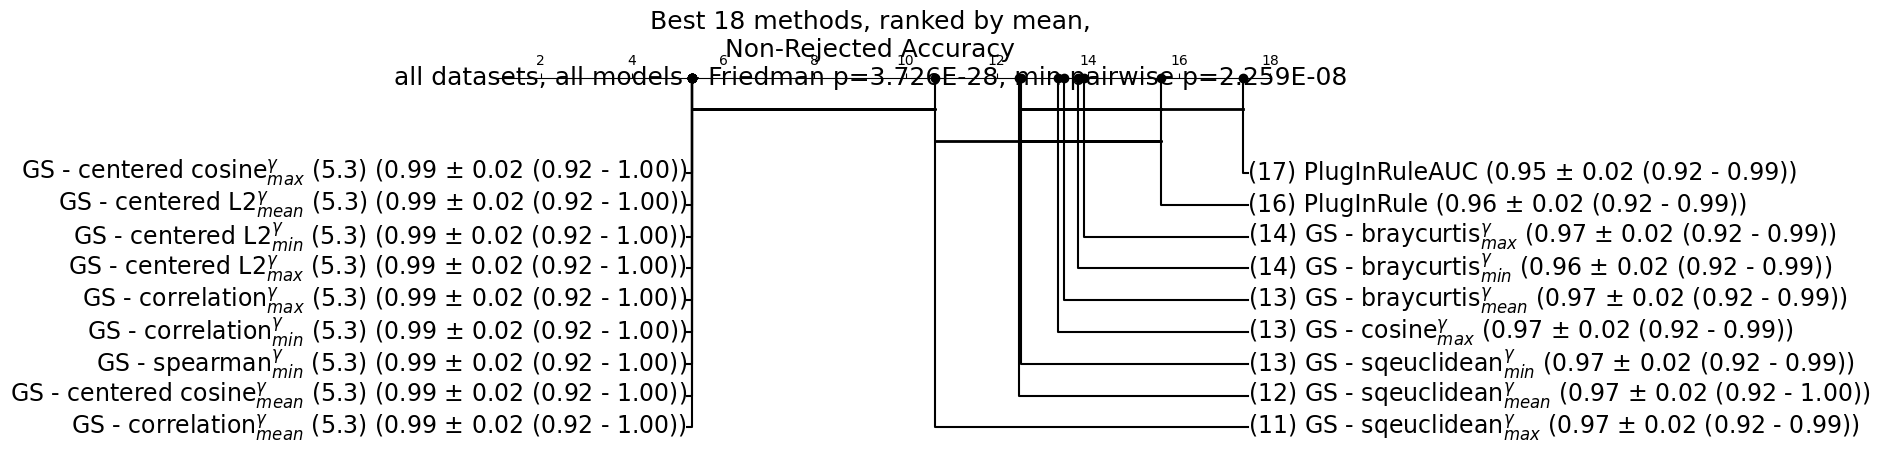

saved at results/figures/comparison_all_methods_rejected_by_coverage.pdf


<Figure size 640x480 with 0 Axes>

Filtered methods count: 362 ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_min_gamma', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_max_gamma', 'growingspheres_CFDistRejector_inf_mean', 'growingspheres_CFDistRejector_inf_mean_gamma', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_min_gamma', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_max_gamma', 'growingspheres_CFDistRejector_l2_mean', 'growingspheres_CFDistRejector_l2_mean_gamma', 'growingspheres_CFDistRejector_sqeuclidean_min', 'growingspheres_CFDistRejector_sqeuclidean_min_gamma', 'growingspheres_CFDistRejector_sqeuclidean_max', 'growingspheres_CFDistRejector_sqeuclidean_max_gamma', 'growingspheres_CFDistRejector_sqeuclidean_mean', 'growingspheres_CFDistRejector_sqeuclidean_mean_gamma', 'growingspheres_CFDistRejector_mae_min', 'growingspheres_CFDistRejector_mae_min_gamma', 'growingsphe

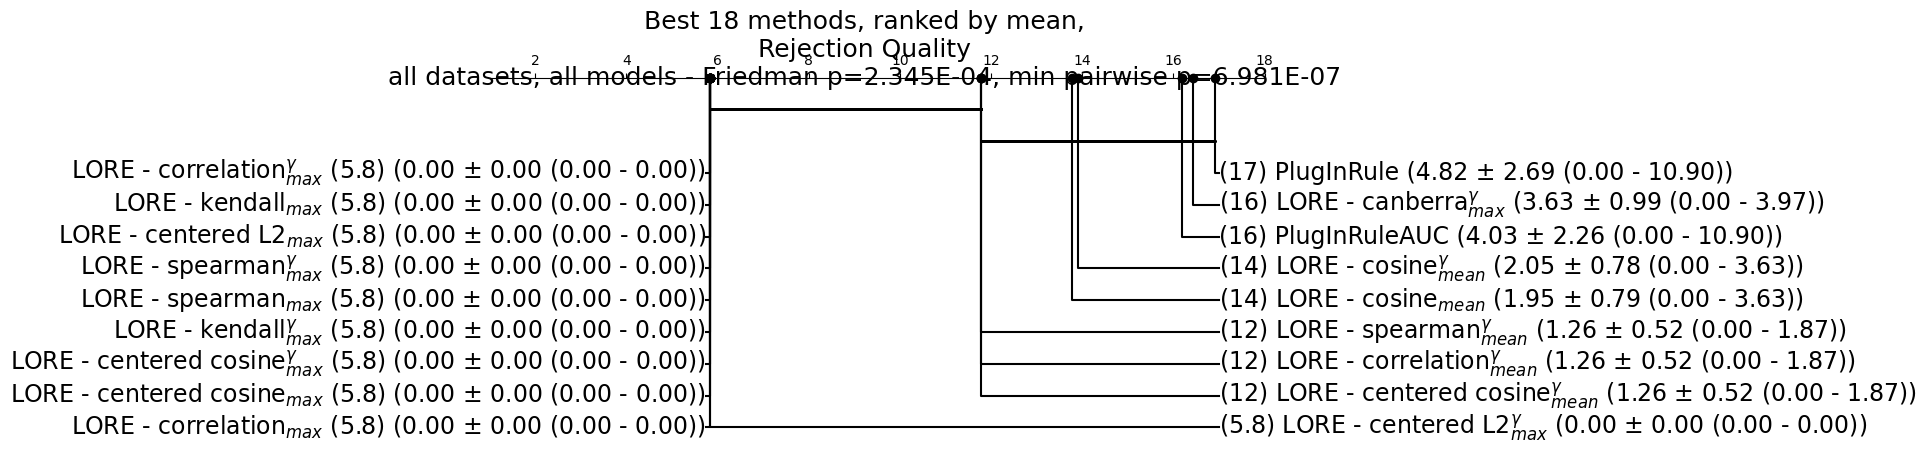

saved at results/figures/comparison_all_methods_rejection_quality_dict.pdf


<Figure size 640x480 with 0 Axes>

Filtered methods count: 362 ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_min_gamma', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_max_gamma', 'growingspheres_CFDistRejector_inf_mean', 'growingspheres_CFDistRejector_inf_mean_gamma', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_min_gamma', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_max_gamma', 'growingspheres_CFDistRejector_l2_mean', 'growingspheres_CFDistRejector_l2_mean_gamma', 'growingspheres_CFDistRejector_sqeuclidean_min', 'growingspheres_CFDistRejector_sqeuclidean_min_gamma', 'growingspheres_CFDistRejector_sqeuclidean_max', 'growingspheres_CFDistRejector_sqeuclidean_max_gamma', 'growingspheres_CFDistRejector_sqeuclidean_mean', 'growingspheres_CFDistRejector_sqeuclidean_mean_gamma', 'growingspheres_CFDistRejector_mae_min', 'growingspheres_CFDistRejector_mae_min_gamma', 'growingsphe

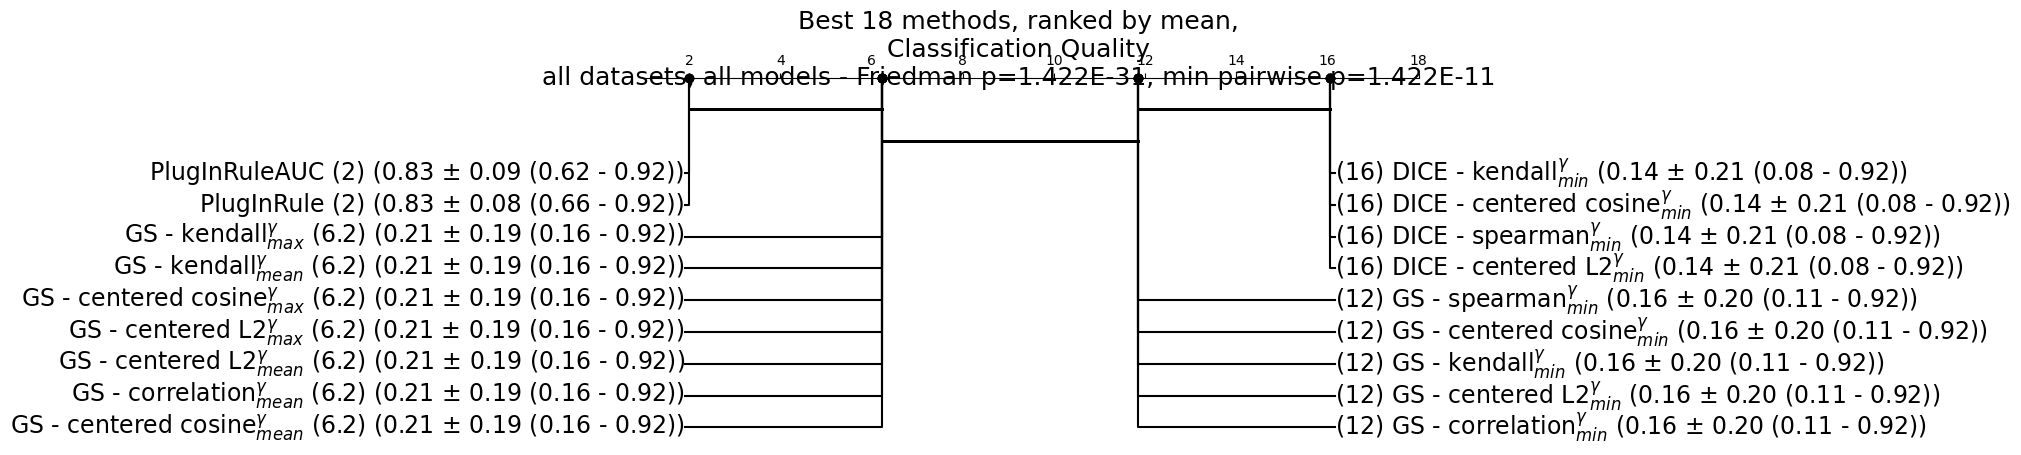

saved at results/figures/comparison_all_methods_classification_quality_dict.pdf


<Figure size 640x480 with 0 Axes>

In [33]:
for metric in ["rejected_by_coverage","rejection_quality_dict","classification_quality_dict"]:
    # select only the two moons dataset

    methods, values, title = rq_analyzer.create_comparison_for_visualization(filter_criteria={},
                                                                         metric=metric,
                                                                         top_n=16)
    print(title)
    
    title = f"Best {len(methods)} methods, ranked by mean,\n"+fancy_metric[metric]+"\nall datasets, all models"
    create_df_and_check2(methods, values[:,:].T, title, 
                         show=True, 
                         metrica=fancy_metric[metric],
                         invert = metric == 'rejection_quality_dict',
                         meanstd=True,
                         minmax=True
                         )
    plt.savefig(f"results/figures/comparison_all_methods_{metric}.pdf")
    print("saved at",f"results/figures/comparison_all_methods_{metric}.pdf")
    plt.show()
    plt.close()


Dataset: <built-in function all>
Metric  rejected_by_coverage
Best method: PlugInRule
Components:  {'cf_generator': 'PlugInRule', 'rejector_type': None, 'distance': None, 'aggregation': None, 'distribution': None, 'is_baseline': True}
Score: 0.9366

Filtered methods count: 362 ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_min_gamma', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_max_gamma', 'growingspheres_CFDistRejector_inf_mean', 'growingspheres_CFDistRejector_inf_mean_gamma', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_min_gamma', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_max_gamma', 'growingspheres_CFDistRejector_l2_mean', 'growingspheres_CFDistRejector_l2_mean_gamma', 'growingspheres_CFDistRejector_sqeuclidean_min', 'growingspheres_CFDistRejector_sqeuclidean_min_gamma', 'growingspheres_CFDistRejector_sqeuclidean_max', 'growingsph

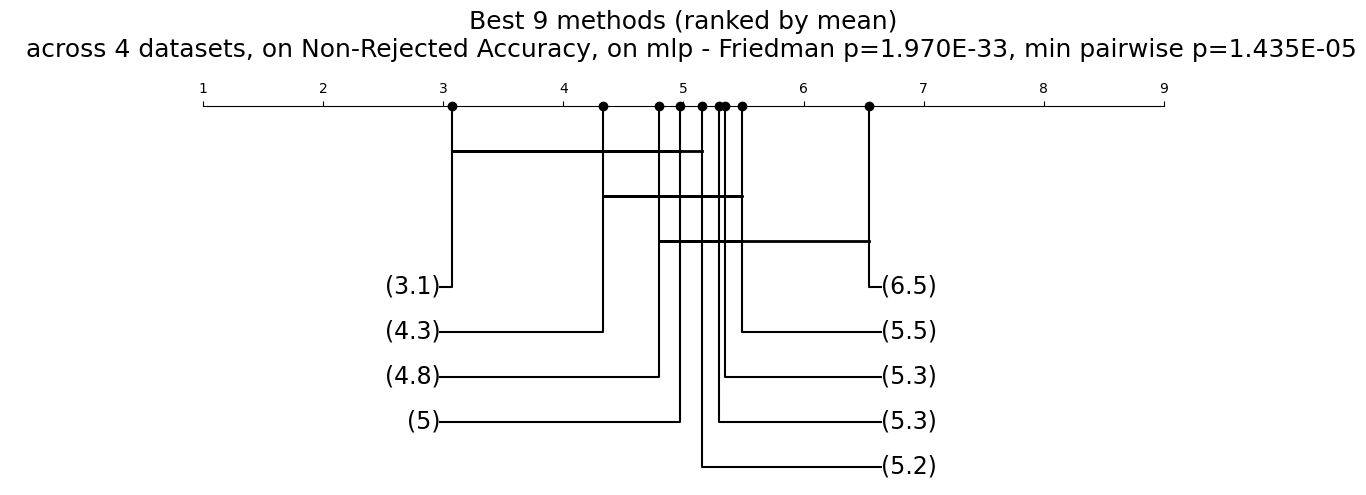

Filtered methods count: 362 ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_min_gamma', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_max_gamma', 'growingspheres_CFDistRejector_inf_mean', 'growingspheres_CFDistRejector_inf_mean_gamma', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_min_gamma', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_max_gamma', 'growingspheres_CFDistRejector_l2_mean', 'growingspheres_CFDistRejector_l2_mean_gamma', 'growingspheres_CFDistRejector_sqeuclidean_min', 'growingspheres_CFDistRejector_sqeuclidean_min_gamma', 'growingspheres_CFDistRejector_sqeuclidean_max', 'growingspheres_CFDistRejector_sqeuclidean_max_gamma', 'growingspheres_CFDistRejector_sqeuclidean_mean', 'growingspheres_CFDistRejector_sqeuclidean_mean_gamma', 'growingspheres_CFDistRejector_mae_min', 'growingspheres_CFDistRejector_mae_min_gamma', 'growingsphe

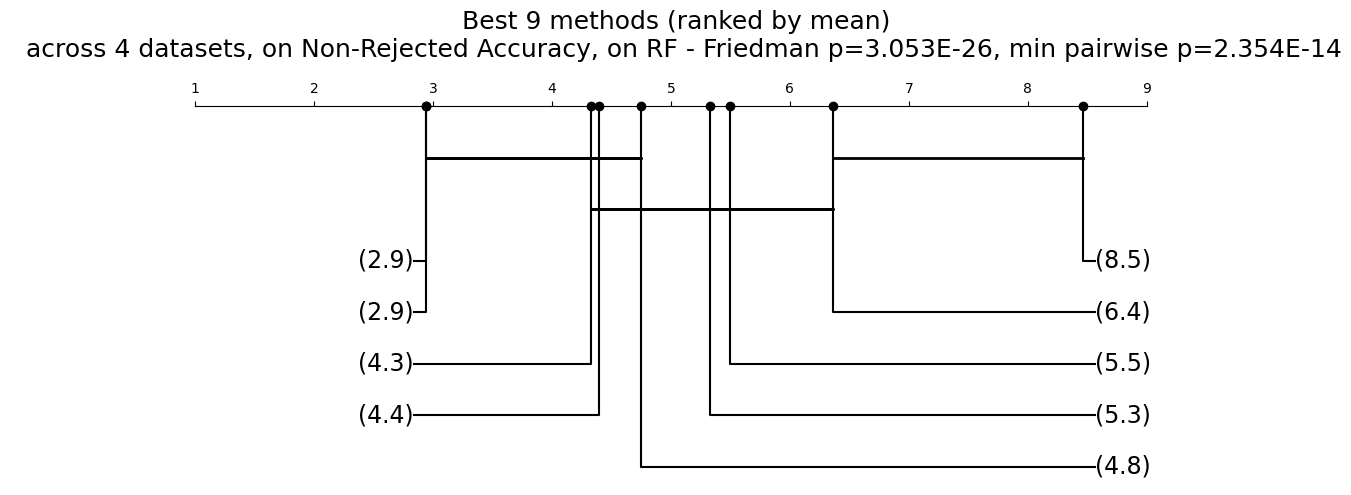

Filtered methods count: 362 ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_min_gamma', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_max_gamma', 'growingspheres_CFDistRejector_inf_mean', 'growingspheres_CFDistRejector_inf_mean_gamma', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_min_gamma', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_max_gamma', 'growingspheres_CFDistRejector_l2_mean', 'growingspheres_CFDistRejector_l2_mean_gamma', 'growingspheres_CFDistRejector_sqeuclidean_min', 'growingspheres_CFDistRejector_sqeuclidean_min_gamma', 'growingspheres_CFDistRejector_sqeuclidean_max', 'growingspheres_CFDistRejector_sqeuclidean_max_gamma', 'growingspheres_CFDistRejector_sqeuclidean_mean', 'growingspheres_CFDistRejector_sqeuclidean_mean_gamma', 'growingspheres_CFDistRejector_mae_min', 'growingspheres_CFDistRejector_mae_min_gamma', 'growingsphe

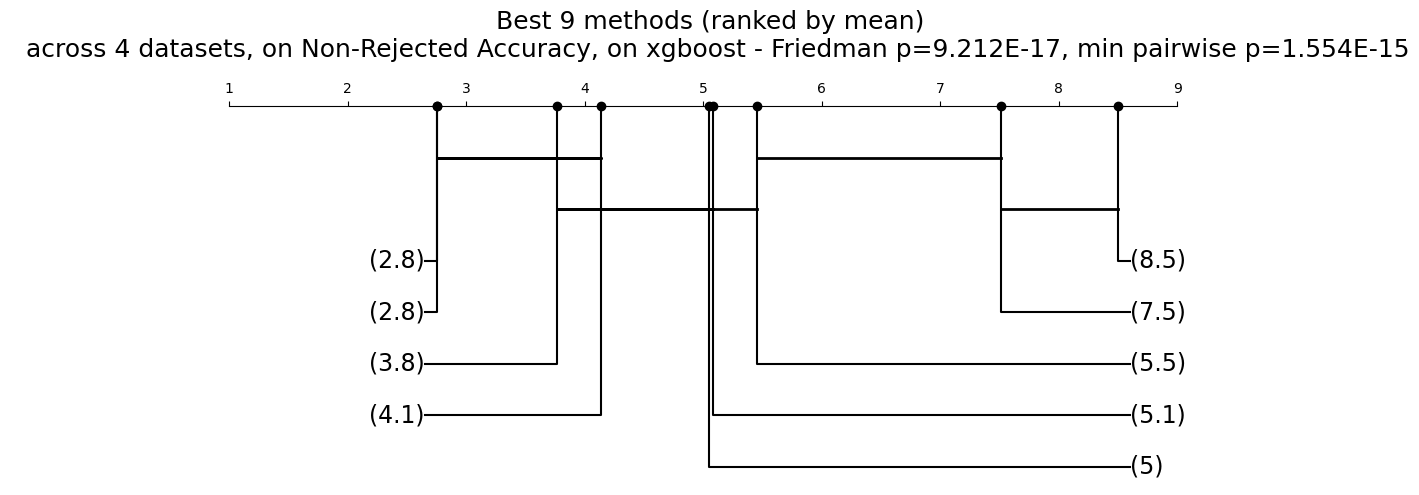

Filtered methods count: 362 ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_min_gamma', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_max_gamma', 'growingspheres_CFDistRejector_inf_mean', 'growingspheres_CFDistRejector_inf_mean_gamma', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_min_gamma', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_max_gamma', 'growingspheres_CFDistRejector_l2_mean', 'growingspheres_CFDistRejector_l2_mean_gamma', 'growingspheres_CFDistRejector_sqeuclidean_min', 'growingspheres_CFDistRejector_sqeuclidean_min_gamma', 'growingspheres_CFDistRejector_sqeuclidean_max', 'growingspheres_CFDistRejector_sqeuclidean_max_gamma', 'growingspheres_CFDistRejector_sqeuclidean_mean', 'growingspheres_CFDistRejector_sqeuclidean_mean_gamma', 'growingspheres_CFDistRejector_mae_min', 'growingspheres_CFDistRejector_mae_min_gamma', 'growingsphe

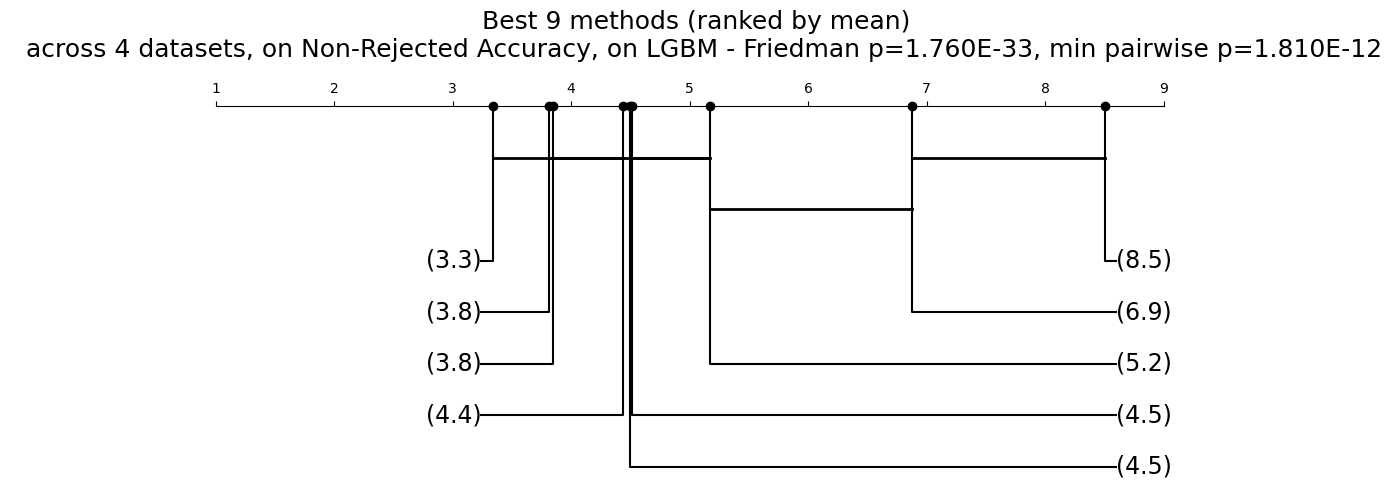

<Figure size 640x480 with 0 Axes>

In [29]:
for metric in ["rejected_by_coverage"]:# dictionaries[dataset].keys():
        overall_best = rq_analyzer.find_overall_best_method(metric=metric)
        print(f"Dataset: {all}")
        print("Metric ",metric)
        print(f"Best method: {overall_best['best_method']}")

        print("Components: ", overall_best['method_components'])
        print(f"Score: {overall_best['best_score']:.4f}")
        print()
        
        # get the values for the specific dataset and metric
        for model in fancy_model.keys():
            methods, values, title = rq_analyzer.create_comparison_for_visualization(
                filter_criteria={},
                dataset='all',
                metric=metric,
                model=model,
            top_n=8
            )
            print(title)
            title = title.replace("/"," ")
            title = title.replace("(ranked by mean):","(ranked by mean)\n").replace("Top","Best")
            title = title.replace("across 1 datasets","on "+fancy_dataset.get(dataset,dataset))
            title = title.replace("1 metrics","on "+fancy_metric.get(metric,metric))
            title = title.replace("1 models","on "+fancy_model.get(model,model))
            #title =f"Comparinson of the top {len(methods)} methods\n"+f"on {fancy_dataset.get(dataset,dataset)} - {fancy_model.get(model,model)} - {fancy_metric.get(metric,metric)}, for model {fancy_model.get(model,model)}"
            vv = values[:,:].T      
            create_df_and_check2(methods, vv, 
                                title, show=True, invert=metric=='rejection_quality_dict',
                                minmax=True
                                )
        #if True:
        # save the figure
        plt.savefig(f"results/figures/0_{metric}_{0}_comparison.pdf", bbox_inches='tight')
        plt.show()
        plt.close()
# input()



Filtered methods count: 30 ['growingspheres_CFDistRejector_spearman_min', 'growingspheres_CFDistRejector_spearman_min_gamma', 'growingspheres_CFDistRejector_spearman_max', 'growingspheres_CFDistRejector_spearman_max_gamma', 'growingspheres_CFDistRejector_spearman_mean', 'growingspheres_CFDistRejector_spearman_mean_gamma', 'ils_CFDistRejector_spearman_min', 'ils_CFDistRejector_spearman_min_gamma', 'ils_CFDistRejector_spearman_max', 'ils_CFDistRejector_spearman_max_gamma', 'ils_CFDistRejector_spearman_mean', 'ils_CFDistRejector_spearman_mean_gamma', 'ils<latent_CFDistRejector_spearman_min', 'ils<latent_CFDistRejector_spearman_min_gamma', 'ils<latent_CFDistRejector_spearman_max', 'ils<latent_CFDistRejector_spearman_max_gamma', 'ils<latent_CFDistRejector_spearman_mean', 'ils<latent_CFDistRejector_spearman_mean_gamma', 'lore_CFDistRejector_spearman_min', 'lore_CFDistRejector_spearman_min_gamma', 'lore_CFDistRejector_spearman_max', 'lore_CFDistRejector_spearman_max_gamma', 'lore_CFDistReject

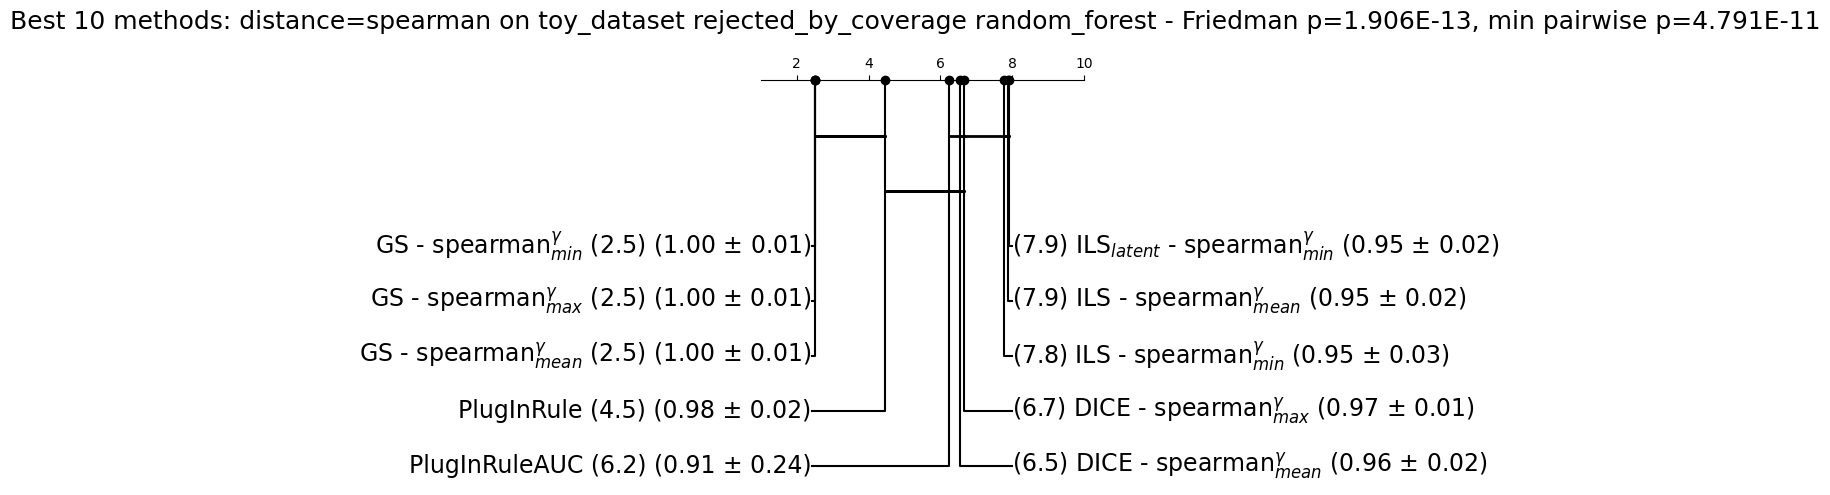

In [51]:
# check the value of the Random Forest when the distance is "GS - spearman$^{\gamma}_{min}$" for all the datasets and metric rejected_by_coverage

for metric in ["rejected_by_coverage"]:
    methods, values, title = rq_analyzer.create_comparison_for_visualization(
        filter_criteria={'distance': "spearman"},
        dataset=["toy_dataset"],
        metric=metric,
        model='random_forest',
        top_n=8
    )
    print(title)
    title = title.replace("/"," ")
    title = title.replace("(ranked by mean):","(ranked by mean)\n").replace("Top","Best")
    #title = title.replace("across 1 datasets","on "+fancy_dataset.get(dataset,dataset))
    title = title.replace("across 1 datasets","on all datasets")
    title = title.replace("1 metrics","on "+fancy_metric.get(metric,metric))
    title = title.replace("1 models","on "+fancy_model.get('random_forest','random_forest'))
    vv = values[:,:].T      
    create_df_and_check2(methods, vv, 
                        title, show=True, invert=metric=='rejection_quality_dict',
                        )

Dataset: <built-in function all>
Metric  rejected_by_coverage
Best method: dice_CFDistRejector_minkowski_max_gamma
Componetns:  {}
Score: 0.9868

Filtered methods count: 722 ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFTreeRejector_inf_min', 'growingspheres_CFDistRejector_inf_min_gamma', 'growingspheres_CFTreeRejector_inf_min_gamma', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFTreeRejector_inf_max', 'growingspheres_CFDistRejector_inf_max_gamma', 'growingspheres_CFTreeRejector_inf_max_gamma', 'growingspheres_CFDistRejector_inf_mean', 'growingspheres_CFTreeRejector_inf_mean', 'growingspheres_CFDistRejector_inf_mean_gamma', 'growingspheres_CFTreeRejector_inf_mean_gamma', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFTreeRejector_l2_min', 'growingspheres_CFDistRejector_l2_min_gamma', 'growingspheres_CFTreeRejector_l2_min_gamma', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFTreeRejector_l2_max', 'growingsp

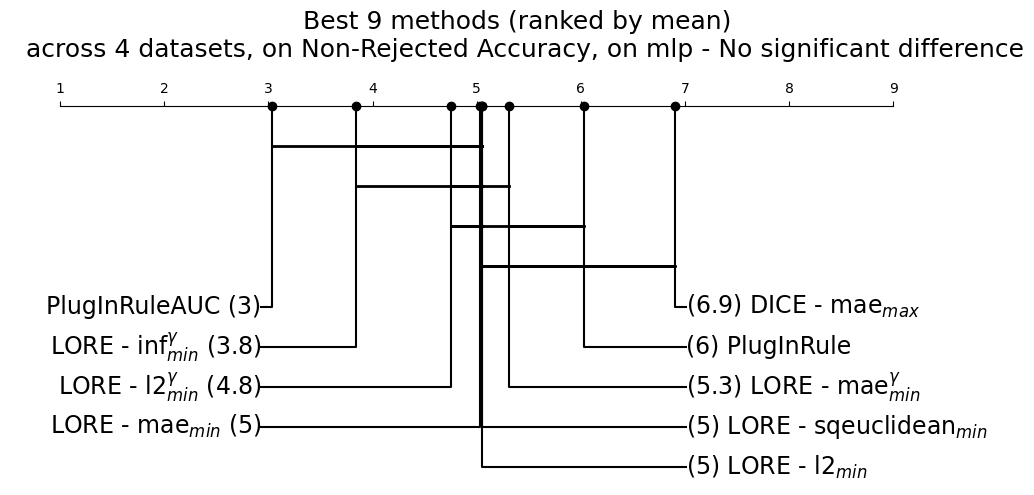

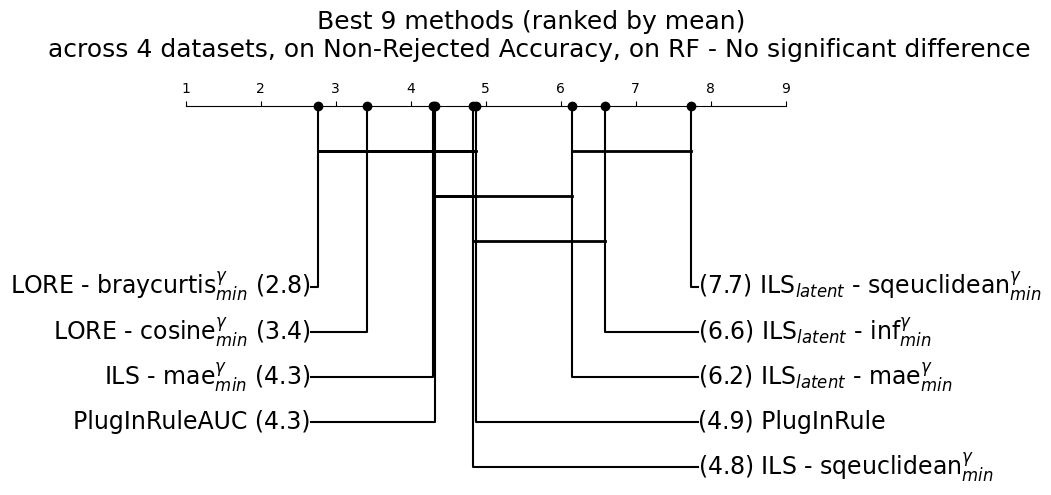

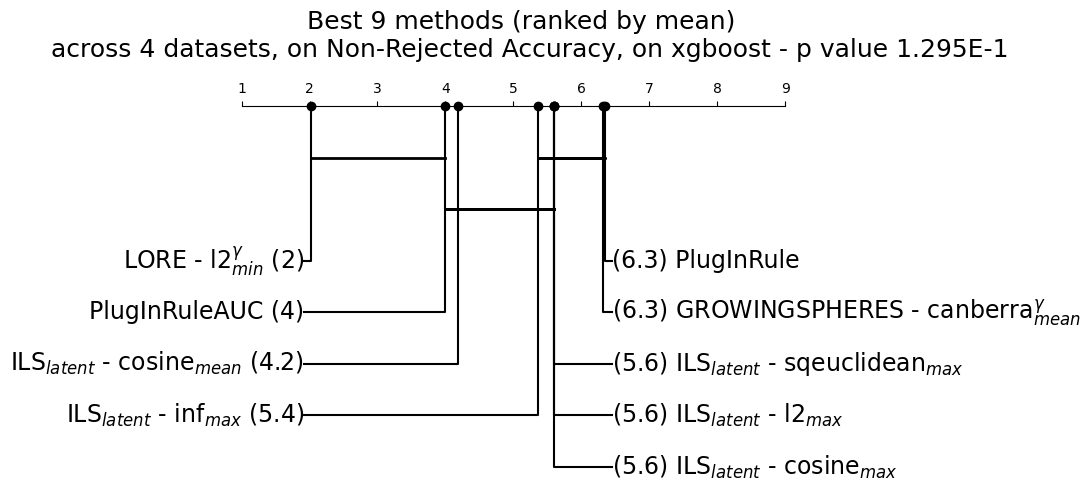

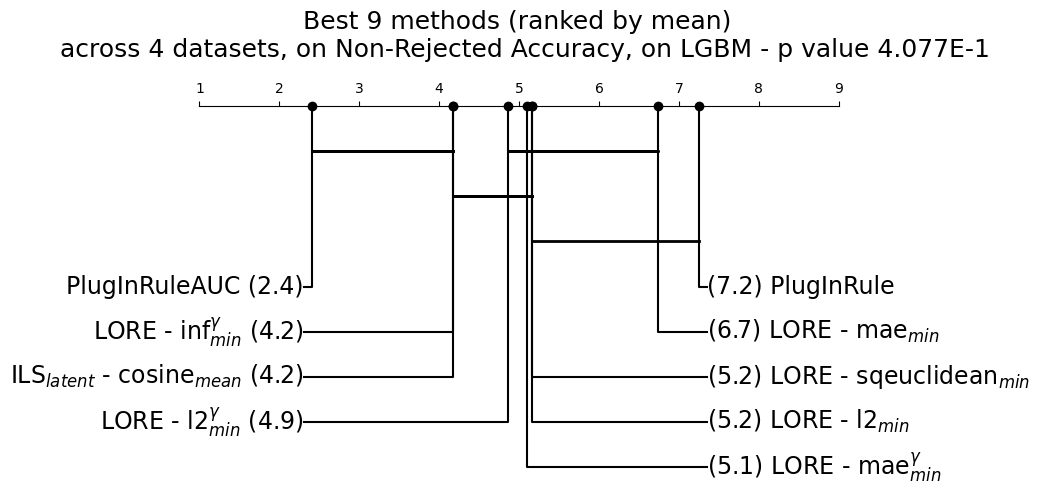

In [19]:
for metric in ["rejected_by_coverage"]:# dictionaries[dataset].keys():
        overall_best = rq_analyzer.find_overall_best_method(metric=metric)
        print(f"Dataset: {all}")
        print("Metric ",metric)
        print(f"Best method: {overall_best['best_method']}")

        print("Componetns: ", overall_best['method_components'])
        print(f"Score: {overall_best['best_score']:.4f}")
        print()
        
        # get the values for the specific dataset and metric
        for model in fancy_model.keys():
            methods, values, title = rq_analyzer.create_comparison_for_visualization(
                filter_criteria={},
                dataset='all',
                metric=metric,
                model=model,
            top_n=8
        )
            print(title)
            title = title.replace("/"," ")
            title = title.replace("(ranked by mean):","(ranked by mean)\n").replace("Top","Best")
            title = title.replace("across 1 datasets","on "+fancy_dataset.get(dataset,dataset))
            title = title.replace("1 metrics","on "+fancy_metric.get(metric,metric))
            title = title.replace("1 models","on "+fancy_model.get(model,model))
            #title =f"Comparinson of the top {len(methods)} methods\n"+f"on {fancy_dataset.get(dataset,dataset)} - {fancy_model.get(model,model)} - {fancy_metric.get(metric,metric)}, for model {fancy_model.get(model,model)}"
            vv = values[:,:].T      
            create_df_and_check(methods, vv, 
                                title, show=True, invert=metric=='rejection_quality_dict',
                                )
        #if True:
        # save the figure
        plt.savefig(f"results/figures/0_{metric}_{0}_comparison.pdf", bbox_inches='tight')
        plt.show()
        plt.close()
# input()



Dataset: toy_dataset
Metric  rejected_by_coverage
Best method: growingspheres_CFDistRejector_sqeuclidean_max_gamma
Componetns:  {'cf_generator': 'growingspheres', 'rejector_type': 'CFDistRejector', 'distance': 'sqeuclidean', 'aggregation': 'max', 'distribution': 'gamma', 'is_baseline': False}
Score: 0.9007

Filtered methods count: 362 ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_min_gamma', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_max_gamma', 'growingspheres_CFDistRejector_inf_mean', 'growingspheres_CFDistRejector_inf_mean_gamma', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_min_gamma', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_max_gamma', 'growingspheres_CFDistRejector_l2_mean', 'growingspheres_CFDistRejector_l2_mean_gamma', 'growingspheres_CFDistRejector_sqeuclidean_min', 'growingspheres_CFDistRejector_sqeuclidean_min_gamma', '

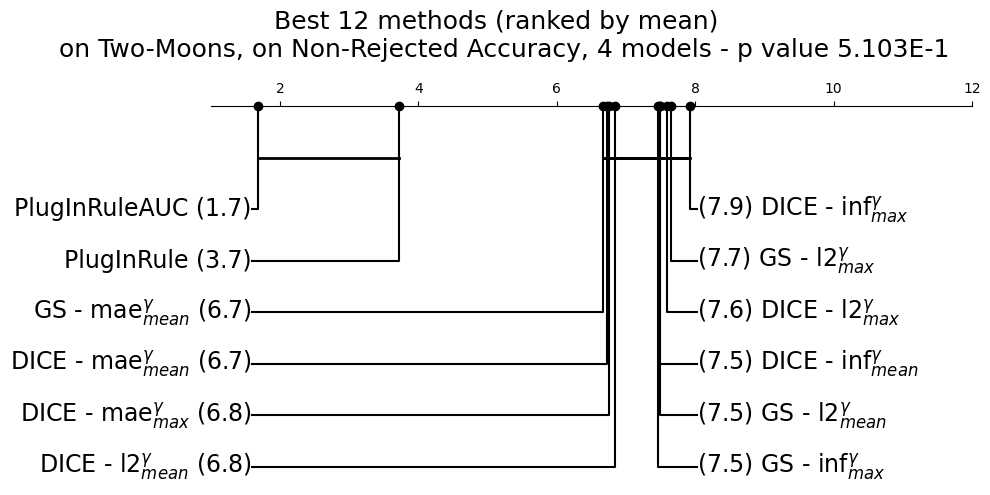

Dataset: german_credit
Metric  rejected_by_coverage
Best method: growingspheres_CFDistRejector_sqeuclidean_max_gamma
Componetns:  {'cf_generator': 'growingspheres', 'rejector_type': 'CFDistRejector', 'distance': 'sqeuclidean', 'aggregation': 'max', 'distribution': 'gamma', 'is_baseline': False}
Score: 0.9007

Filtered methods count: 362 ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_min_gamma', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_max_gamma', 'growingspheres_CFDistRejector_inf_mean', 'growingspheres_CFDistRejector_inf_mean_gamma', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_min_gamma', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_max_gamma', 'growingspheres_CFDistRejector_l2_mean', 'growingspheres_CFDistRejector_l2_mean_gamma', 'growingspheres_CFDistRejector_sqeuclidean_min', 'growingspheres_CFDistRejector_sqeuclidean_min_gamma',

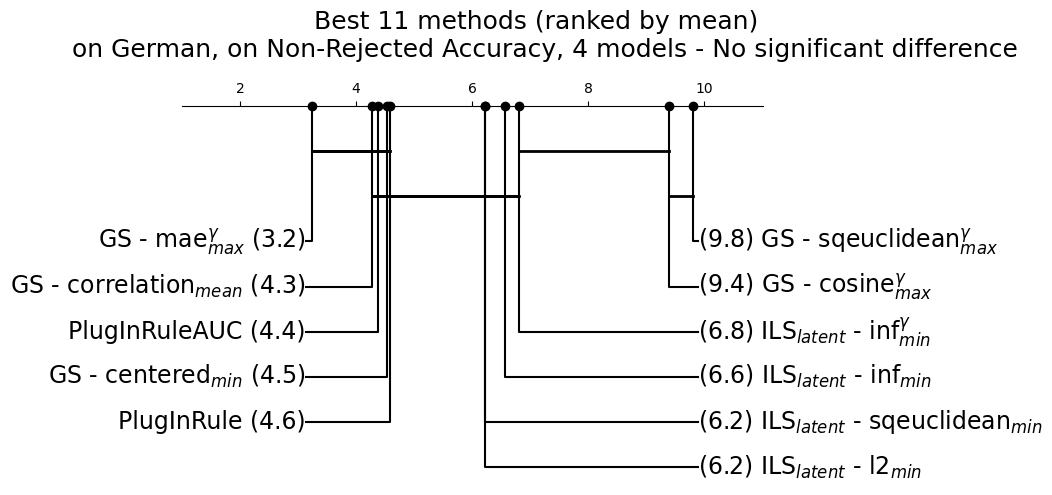

In [20]:
for dataset in dictionaries.keys():
    for metric in ["rejected_by_coverage"]:# dictionaries[dataset].keys():
        overall_best = rq_analyzer.find_overall_best_method(metric=metric)
        print(f"Dataset: {dataset}")
        print("Metric ",metric)
        print(f"Best method: {overall_best['best_method']}")

        print("Componetns: ", overall_best['method_components'])
        print(f"Score: {overall_best['best_score']:.4f}")
        print()
        
        # get the values for the specific dataset and metric
        methods, values, title = rq_analyzer.create_comparison_for_visualization(
            filter_criteria={},
            dataset=dataset,
            metric=metric,
            model='all',
            top_n=10
        )
        print(title)
        title = title.replace("/"," ")
        title = title.replace("(ranked by mean):","(ranked by mean)\n").replace("Top","Best")
        title = title.replace("across 1 datasets","on "+fancy_dataset.get(dataset,dataset))
        title = title.replace("1 metrics","on "+fancy_metric.get(metric,metric))
        title = title.replace("1 models","on all models")
        #title =f"Comparinson of the top {len(methods)} methods\n"+f"on {fancy_dataset.get(dataset,dataset)} - {fancy_model.get(model,model)} - {fancy_metric.get(metric,metric)}, for model {fancy_model.get(model,model)}"
        create_df_and_check(methods, values[:,:].T, 
                            title, show=True, invert=metric=='rejection_quality_dict',
                            )
        #if True:
        # save the figure
        plt.savefig(f"results/figures/{dataset}_{metric}_0_all_comparison.pdf", bbox_inches='tight')
        plt.show()
        plt.close()
# input()



In [60]:
for dataset in dictionaries.keys():
    for metric in ["rejected_by_coverage"]:# dictionaries[dataset].keys():
        overall_best = rq_analyzer.find_overall_best_method(metric=metric)
        print(f"Dataset: {dataset}")
        print("Metric ",metric)
        print(f"Best method: {overall_best['best_method']}")

        print("Componetns: ", overall_best['method_components'])
        print(f"Score: {overall_best['best_score']:.4f}")
        print()
        for model in dictionaries[dataset][metric].keys():
        # get the values for the specific dataset and metric
            methods, values, title = rq_analyzer.create_comparison_for_visualization(
                filter_criteria={},

                dataset=dataset,
                metric=metric,
                model=model,#'all',
                top_n=14
            )
            print(title)
            title = title.replace("/"," ")
            title = title.replace("(ranked by mean):","(ranked by mean)\n").replace("Top","Best")
            title = title.replace("across 1 datasets","on "+fancy_dataset.get(dataset,dataset))
            title = title.replace("1 metrics","on "+fancy_metric.get(metric,metric))
            title = title.replace("1 models","on all models")
            title = title.replace("on all models","on "+fancy_model.get(model,model))
            title =f"Comparinson of the top {len(methods)} methods\n"+f"on {fancy_dataset.get(dataset,dataset)} - {fancy_model.get(model,model)} - {fancy_metric.get(metric,metric)}, for model {fancy_model.get(model,model)}"
            create_df_and_check(methods, values[:,:16].T, 
                                title, show=True, invert=metric=='rejection_quality_dict',
                                )
            #if True:
            # save the figure
            plt.savefig(f"results/figures/{dataset}_{metric}_{model}_comparison.pdf", bbox_inches='tight')
            plt.close()
    # input()



Dataset: german_credit
Metric  rejected_by_coverage
Best method: PlugInRule
Componetns:  {'cf_generator': 'PlugInRule', 'rejector_type': None, 'distance': None, 'aggregation': None, 'distribution': None, 'is_baseline': True}
Score: 0.9366

Filtered methods count: 482 ['PlugInRule', 'PlugInRuleAUC', 'ils_CFDistRejector_inf_min', 'ils_CFTreeRejector_inf_min', 'ils_CFDistRejector_inf_min_gamma', 'ils_CFTreeRejector_inf_min_gamma', 'ils_CFDistRejector_inf_max', 'ils_CFTreeRejector_inf_max', 'ils_CFDistRejector_inf_max_gamma', 'ils_CFTreeRejector_inf_max_gamma', 'ils_CFDistRejector_inf_mean', 'ils_CFTreeRejector_inf_mean', 'ils_CFDistRejector_inf_mean_gamma', 'ils_CFTreeRejector_inf_mean_gamma', 'ils_CFDistRejector_cosine_min', 'ils_CFTreeRejector_cosine_min', 'ils_CFDistRejector_cosine_min_gamma', 'ils_CFTreeRejector_cosine_min_gamma', 'ils_CFDistRejector_cosine_max', 'ils_CFTreeRejector_cosine_max', 'ils_CFDistRejector_cosine_max_gamma', 'ils_CFTreeRejector_cosine_max_gamma', 'ils_CFDistR

In [33]:
overall_best.keys()

dict_keys(['best_method', 'best_score', 'top_10_methods', 'method_components', 'analysis_details'])

In [34]:
overall_best["analysis_details"]

{'metric': 'rejected_by_coverage',
 'aggregation': 'mean',
 'total_methods_compared': 914}

In [35]:
print(f"Top 10 methods: {overall_best['top_10_methods']}")

Top 10 methods: {'lore_CFDistRejector_l1_min': 0.96505170889046, 'lore_CFDistRejector_minkowski_min': 0.964471306104131, 'dice_CFDistRejector_l1_min': 0.9632210320717348, 'lore_CFDistRejector_chebyshev_min': 0.9631491244733016, 'dice_CFDistRejector_wasserstein_mean': 0.9628153869927715, 'dice_CFDistRejector_l1_mean': 0.9628116126486976, 'dice_CFDistRejector_wasserstein_max': 0.9617223585693099, 'dice_CFDistRejector_minkowski_min': 0.9613941867832833, 'dice_CFDistRejector_l1_max': 0.9611692475644695, 'dice_CFDistRejector_wasserstein_min': 0.9609744948377744}


In [36]:
comparison = rq_analyzer.compare_cf_generators('ils<latent', 'ils', model="lgbm")
print(f"Winner: {comparison['winner']}")
comparison.keys()

Winner: ils<latent


dict_keys(['comparison', 'model', 'metric', 'winner', 'winner_advantage', 'ils<latent_stats', 'ils_stats', 'statistical_significance', 'detailed_data'])

In [37]:
check_best_metric.keys()

NameError: name 'check_best_metric' is not defined

In [38]:
#
for metric_name in ["l2","l1","minkowski","cosine"]:
    check_best_metric = rq_analyzer.find_best_distance_metric(distance_type=metric_name)
    print(check_best_metric.keys())
    print(f"Best:  {check_best_metric['best_method']}")
    print(f"Score: {check_best_metric['all_performance']}")
    

dict_keys(['best_method', 'best_value', 'all_performance', 'component', 'component_value'])
Best:  dice_CFDistRejector_l2_mean_gamma
Score: {'dice_CFDistRejector_l2_max': 2.6066032913435984, 'dice_CFDistRejector_l2_max_gamma': 3.5146124908884597, 'dice_CFDistRejector_l2_mean': 2.7657903228275793, 'dice_CFDistRejector_l2_mean_gamma': 4.028050003244705, 'dice_CFDistRejector_l2_min': 2.5552150362034727, 'dice_CFDistRejector_l2_min_gamma': 3.993808402414072, 'dice_CFTreeRejector_l2_max': 0.0, 'dice_CFTreeRejector_l2_max_gamma': 0.0, 'dice_CFTreeRejector_l2_mean': 0.0, 'dice_CFTreeRejector_l2_mean_gamma': 0.0, 'dice_CFTreeRejector_l2_min': 0.0, 'dice_CFTreeRejector_l2_min_gamma': 0.0, 'growingspheres_CFDistRejector_l2_max': 2.905174288799156, 'growingspheres_CFDistRejector_l2_max_gamma': 2.7803630359959843, 'growingspheres_CFDistRejector_l2_mean': 2.7571757734287012, 'growingspheres_CFDistRejector_l2_mean_gamma': 2.4221646722047323, 'growingspheres_CFDistRejector_l2_min': 2.7830426610212635

KeyError: 'best_method'

In [74]:
'''methods, values, title = rq_analyzer.create_comparison_for_visualization(
    filter_criteria={'distance': 'minkowski', 'aggregation': 'max'},
    dataset='german_credit',
    metric='rejection_quality_dict',
    model='mlp',
    top_n=10
)

# Now use with your function
methods, values, title'''

"methods, values, title = rq_analyzer.create_comparison_for_visualization(\n    filter_criteria={'distance': 'minkowski', 'aggregation': 'max'},\n    dataset='german_credit',\n    metric='rejection_quality_dict',\n    model='mlp',\n    top_n=10\n)\n\n# Now use with your function\nmethods, values, title"

In [41]:
from itertools import product
combinations = list(product(['ils<latent','ils','dice','lore',"growingspheres"], repeat=2))
combinations = [comb for comb in combinations if comb[0] != comb[1]]

combinations # combination should be is symmetric
combinations = [comb for i,comb in enumerate(combinations) if (comb[1], comb[0]) not in combinations[i+1:]]
combinations


[('ils', 'ils<latent'),
 ('dice', 'ils<latent'),
 ('dice', 'ils'),
 ('lore', 'ils<latent'),
 ('lore', 'ils'),
 ('lore', 'dice'),
 ('growingspheres', 'ils<latent'),
 ('growingspheres', 'ils'),
 ('growingspheres', 'dice'),
 ('growingspheres', 'lore')]

In [43]:

for model in ["mlp", "xgboost", "lgbm","random_forest"]:
    for c in combinations:
        gen1, gen2 = c
        comparison = rq_analyzer.compare_cf_generators(gen1, gen2, model=model, metric='rejected_by_coverage')
        print(f"Model: {model} - {gen1} vs {gen2}: Winner: {comparison['winner']} with advantage {comparison['winner_advantage']:.4f}")
        pairwise_results = compare_generators_pairwise(
        dictionaries,
        generators=[gen1, gen2],  # the generators
        metric='rejected_by_coverage',
        model=model
        )

Model: mlp - ils vs ils<latent: Winner: ils<latent with advantage 0.0070
=== PAIRWISE GENERATOR COMPARISON ===
Comparing: ['ils', 'ils<latent']
Metric: rejected_by_coverage, Model: mlp

🥊 ils vs ils<latent:
   Winner: ils<latent
   Advantage: 0.0070
   ils: 0.4291
   ils<latent: 0.4361
   Statistical test: p=0.8165 (not significant)

Model: mlp - dice vs ils<latent: Winner: dice with advantage 0.0150
=== PAIRWISE GENERATOR COMPARISON ===
Comparing: ['dice', 'ils<latent']
Metric: rejected_by_coverage, Model: mlp

🥊 dice vs ils<latent:
   Winner: dice
   Advantage: 0.0150
   dice: 0.4511
   ils<latent: 0.4361
   Statistical test: p=0.6233 (not significant)

Model: mlp - dice vs ils: Winner: dice with advantage 0.0220
=== PAIRWISE GENERATOR COMPARISON ===
Comparing: ['dice', 'ils']
Metric: rejected_by_coverage, Model: mlp

🥊 dice vs ils:
   Winner: dice
   Advantage: 0.0220
   dice: 0.4511
   ils: 0.4291
   Statistical test: p=0.4704 (not significant)

Model: mlp - lore vs ils<latent: Win